In [ ]:
!pip install networkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 16.4 MB/s eta 0:00:00


In [ ]:
!pip install powerlaw

In [ ]:
import pandas as pd
import networkx as nx
import networkit as nk
from tqdm import tqdm
import numpy as np
from collections import Counter

In [ ]:
from networkx.algorithms.community.modularity_max import greedy_modularity_communities
import powerlaw
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


# TREATMENT GROUP - LLM Papers


### by Disciplines

In [ ]:
# Load the data from the file
file_path = '/content/drive/MyDrive/Project - LLM science of science/updated_dataset/llm-information-entropy.csv'
df = pd.read_csv(file_path)

# Affiliation_disciplines is in a list format
df['affiliation_disciplines'] = df['departments'].apply(eval)

# Create an edgelist
edgelist = []
for index, row in df.iterrows():
    title = row['title']
    disciplines = row['affiliation_disciplines']
    for discipline in disciplines:
        edgelist.append((title, discipline))

# Convert the edgelist to a DataFrame
edgelist_df = pd.DataFrame(edgelist, columns=['source', 'target'])

# Save the edgelist to a CSV file
edgelist_df.to_csv('/content/drive/MyDrive/Project - LLM science of science/data_network/affiliation_disciplines_entropy_edgelist.csv', index=False)

print("Edgelist created and saved as 'edgelist.csv'.")

Edgelist created and saved as 'edgelist.csv'.


In [ ]:
# Map nodes to indices
node_map = {}
index = 0

def get_node_index(node):
    global index
    if node not in node_map:
        node_map[node] = index
        index += 1
    return node_map[node]

# Determine the number of unique nodes
num_nodes = len(set(edgelist_df['source']).union(set(edgelist_df['target'])))

# Create a bipartite graph with the predefined number of nodes
B = nk.graph.Graph(num_nodes, weighted=True, directed=False)

# Add edges to the bipartite graph
for _, row in edgelist_df.iterrows():
    paper = get_node_index(row['source'])
    discipline = get_node_index(row['target'])
    B.addEdge(paper, discipline)

In [ ]:
# Collect disciplines
disciplines = set()
for _, row in tqdm(edgelist_df.iterrows(), desc="Collecting disciplines", total=len(edgelist_df)):
    disciplines.add(row['target'])

# Create a projection onto disciplines
projected_graph = nk.graph.Graph(len(disciplines), weighted=True, directed=False)

# Map disciplines to indices in the projected graph
discipline_map = {disc: i for i, disc in enumerate(disciplines)}

# Initialize a dictionary to hold the edge weights
edge_weights = {}

# Add edges between disciplines that share at least one paper, with weights
for _, row in tqdm(edgelist_df.iterrows(), desc="Building edge weights", total=len(edgelist_df)):
    paper = get_node_index(row['source'])
    discipline = discipline_map[row['target']]
    for neighbor in B.iterNeighbors(paper):
        neighbor_discipline = None
        for key, value in node_map.items():
            if value == neighbor:
                if key in disciplines:
                    neighbor_discipline = discipline_map[key]
                    break
        if neighbor_discipline is not None and neighbor_discipline != discipline:
            if (discipline, neighbor_discipline) in edge_weights:
                edge_weights[(discipline, neighbor_discipline)] += 1
            elif (neighbor_discipline, discipline) in edge_weights:
                edge_weights[(neighbor_discipline, discipline)] += 1
            else:
                edge_weights[(discipline, neighbor_discipline)] = 1

# Add edges with weights to the projected graph
for (u, v), weight in tqdm(edge_weights.items(), desc="Adding weighted edges", total=len(edge_weights)):
    projected_graph.addEdge(u, v, weight)

Adding weighted edges: 100%|██████████| 33314/33314 [00:00<00:00, 1226984.93it/s]


In [ ]:
# Convert Networkit graph to NetworkX graph
def networkit_to_networkx(nk_graph):
    nx_graph = nx.Graph()
    for u in nk_graph.iterNodes():
        nx_graph.add_node(u)
    for u, v in nk_graph.iterEdges():
        nx_graph.add_edge(u, v, weight=nk_graph.weight(u, v))
    return nx_graph

# Create projected graph
projected_graph = nk.graph.Graph(len(disciplines), weighted=True, directed=False)
for (u, v), weight in edge_weights.items():
    projected_graph.addEdge(u, v, weight)

# Convert projected graph to NetworkX graph
nx_projected_graph = networkit_to_networkx(projected_graph)

Calculating degree centrality...
Calculating closeness centrality...


Processing components: 100%|██████████| 1963/1963 [00:06<00:00, 281.49it/s]


Calculating betweenness centrality...
Calculating eigenvector centrality...
Calculating basic network metrics...
Calculating diameter...
Calculating average shortest path length...


Processing distances: 100%|██████████| 7679/7679 [00:18<00:00, 404.31it/s]
Values less than or equal to 0 in data. Throwing out 0 or negative values


Calculating clustering coefficient...
Calculating degree distribution...
Fitting power law...
Calculating best minimal value for power law fit


Computing degree counts: 100%|██████████| 10131/10131 [00:00<00:00, 1579470.46it/s]


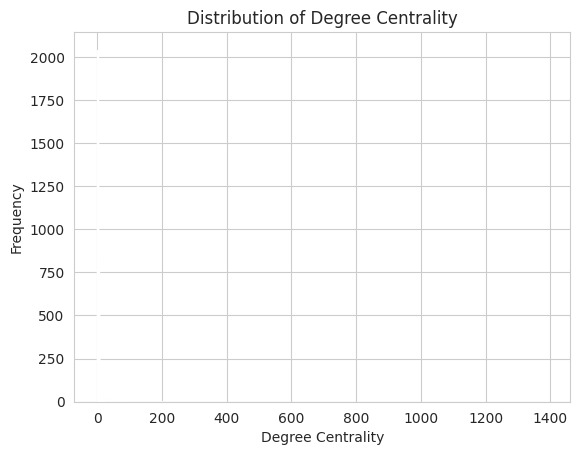

Detecting communities...
Running Clauset-Newman-Moore...
Running PLM community detection...
Converting node indices to names...


Processing eigenvector centrality: 100%|██████████| 10131/10131 [00:00<00:00, 1517860.11it/s]


Results:
Degree Centrality: [('Computer Science', 1392.0), ('Medicine', 1019.0), ('Computer Science and Engineering', 611.0), ('Artificial Intelligence', 586.0), ('Engineering', 385.0), ('Information Technology', 337.0), ('Psychology', 336.0), ('Computer Science and Technology', 334.0), ('Data Science', 319.0), ('Surgery', 313.0)]
Closeness Centrality: [('Independent Scholarship', 0.5), ('Physics and Technology', 0.5), ('Chemistry and Pharmacy', 0.5), ('Food Chemistry and Analytical Chemistry', 0.5), ('Food Biofunctionality', 0.5), ('Physiology and Biochemistry of Nutrition', 0.5), ('Access to Medicines Research Centre', 0.5), ('Technology and Engineering Management', 0.5), ('Probability', 0.5), ('Fundamental and Secondary Education', 0.5)]
Betweenness Centrality: [('Computer Science', 0.09064950211855151), ('Medicine', 0.04266825740689456), ('Artificial Intelligence', 0.03560417398475488), ('Computer Science and Engineering', 0.032674674828096606), ('Education', 0.03075685795564691),

In [ ]:
## Network analysis
# Calculate degree centrality (considering weights)
print("Calculating degree centrality...")
deg_centrality = nk.centrality.DegreeCentrality(projected_graph, ignoreSelfLoops=True)
deg_centrality.run()
degree_centrality_result = deg_centrality.ranking()

# Calculate closeness centrality for each connected component
print("Calculating closeness centrality...")
components = nk.components.ConnectedComponents(projected_graph).run()
closeness_centrality_result = []

for component in tqdm(components.getComponents(), desc="Processing components"):
    subgraph = nk.graphtools.subgraphFromNodes(projected_graph, component)
    closeness_centrality = nk.centrality.Closeness(subgraph, True, subgraph.upperNodeIdBound())
    closeness_centrality.run()
    closeness_centrality_result.extend(closeness_centrality.ranking())

# Sort the combined results
closeness_centrality_result.sort(key=lambda x: x[1], reverse=True)

# Calculate betweenness centrality
print("Calculating betweenness centrality...")
betweenness_centrality = nk.centrality.Betweenness(projected_graph, normalized=True)
betweenness_centrality.run()
betweenness_centrality_result = betweenness_centrality.ranking()

# Calculate eigenvector centrality
print("Calculating eigenvector centrality...")
eigenvector_centrality = nk.centrality.EigenvectorCentrality(projected_graph)
eigenvector_centrality.run()
eigenvector_centrality_result = eigenvector_centrality.ranking()

# Summarize the network
print("Calculating basic network metrics...")
num_nodes = projected_graph.numberOfNodes()
num_edges = projected_graph.numberOfEdges()
density = nk.graphtools.density(projected_graph)

# Extract largest connected component
largest_component = nk.components.ConnectedComponents.extractLargestConnectedComponent(projected_graph, True)

# Calculate diameter of the largest component
print("Calculating diameter...")
diam = nk.distance.Diameter(largest_component, algo=1)
diam.run()
diameter = diam.getDiameter()

# Calculate average shortest path length for the largest component
print("Calculating average shortest path length...")
apsp = nk.distance.APSP(largest_component).run()
distances = apsp.getDistances()

total_distance = 0
total_pairs = 0

for i, row in enumerate(tqdm(distances, desc="Processing distances")):
    for dist in row:
        if dist < float('inf'):
            total_distance += dist
            total_pairs += 1

avg_shortest_path_length = total_distance / total_pairs if total_pairs > 0 else float('inf')

# Calculate clustering coefficient
print("Calculating clustering coefficient...")
clustering_coefficient_result = nk.globals.clustering(projected_graph)

num_components = components.numberOfComponents()
largest_component_size = largest_component.numberOfNodes()

# Calculate the degree distribution
print("Calculating degree distribution...")
dc = nk.centrality.DegreeCentrality(projected_graph)
dc.run()
scores = dc.scores()

# Fit the degree distribution to a power law
print("Fitting power law...")
fit = powerlaw.Fit(scores)
power_law_value = fit.power_law.alpha

# Plot the degree distribution (optional)
degree_counts = {}
for score in tqdm(scores, desc="Computing degree counts"):
    if score in degree_counts:
        degree_counts[score] += 1
    else:
        degree_counts[score] = 1

plt.bar(degree_counts.keys(), degree_counts.values())
plt.xlabel('Degree Centrality')
plt.ylabel('Frequency')
plt.title('Distribution of Degree Centrality')
plt.show()

# Community detection
print("Detecting communities...")
print("Running Clauset-Newman-Moore...")
communities = greedy_modularity_communities(nx_projected_graph)
num_communities_nx = len(communities)

print("Running PLM community detection...")
community_detector = nk.community.PLM(projected_graph)
community_detector.run()
num_communities_nk = len(community_detector.getPartition().getSubsetIds())

# Convert indices back to node names for centrality measures
print("Converting node indices to names...")
reverse_discipline_map = {v: k for k, v in discipline_map.items()}
degree_centrality_named = [(reverse_discipline_map[node], centrality) for node, centrality in tqdm(degree_centrality_result, desc="Processing degree centrality")]
closeness_centrality_named = [(reverse_discipline_map[node], centrality) for node, centrality in tqdm(closeness_centrality_result, desc="Processing closeness centrality")]
betweenness_centrality_named = [(reverse_discipline_map[node], centrality) for node, centrality in tqdm(betweenness_centrality_result, desc="Processing betweenness centrality")]
eigenvector_centrality_named = [(reverse_discipline_map[node], centrality) for node, centrality in tqdm(eigenvector_centrality_result, desc="Processing eigenvector centrality")]

# Print results
print("\nResults:")
print("Degree Centrality:", degree_centrality_named[:10])  # Top 10 nodes
print("Closeness Centrality:", closeness_centrality_named[:10])  # Top 10 nodes
print("Betweenness Centrality:", betweenness_centrality_named[:10])  # Top 10 nodes
print("Eigenvector Centrality:", eigenvector_centrality_named[:10])  # Top 10 nodes

print("\nNetwork Statistics:")
print("Number of Nodes:", num_nodes)
print("Number of Edges:", num_edges)
print("Density:", density)
print("Diameter of Largest Component:", diameter)
print("Average Shortest Path Length:", avg_shortest_path_length)
print("Clustering Coefficient:", clustering_coefficient_result)
print("Number of Components:", num_components)
print("Size of Largest Component:", largest_component_size)
print("Power-law Exponent:", power_law_value)
print("Number of Communities (Networkit - PLM):", num_communities_nk)
print("Number of Communities (NetworkX - Clauset-Newman-Moore):", num_communities_nx)

In [ ]:
# Save the projected graph as a CSV file
edges = []
for u in range(projected_graph.numberOfNodes()):
    for v in projected_graph.iterNeighbors(u):
        weight = projected_graph.weight(u, v)
        edges.append([reverse_discipline_map[u], reverse_discipline_map[v], weight])

projected_disciplines_edgelist = pd.DataFrame(edges, columns=['source', 'target', 'weight'])
projected_disciplines_edgelist.to_csv('/content/drive/MyDrive/Project - LLM science of science/data_network/disciplines_projected_edgelist.csv', index=False)

print("Projected graph saved as 'projected_graph.csv'.")

Projected graph saved as 'projected_graph.csv'.


In [ ]:
file_path = '/content/drive/MyDrive/Project - LLM science of science/data_network/disciplines_projected_edgelist.csv'
projected_df = pd.read_csv(file_path)

# Create a weighted graph from the dataframe
G = nx.from_pandas_edgelist(projected_df, 'source', 'target', ['weight'])

# List of nodes directly connected to Computer Science
CS_connected_nodes = list(G.neighbors('Computer Science'))
print('Disciplines connected to Computer Science:')
print(CS_connected_nodes)

# Analyze Computer Science as an intermediary
intermediary_connections = []

for node in CS_connected_nodes:
    for connected_node in G.neighbors(node):
        if connected_node != 'Computer Science' and connected_node not in CS_connected_nodes:
            weight = G[node][connected_node]['weight'] if 'weight' in G[node][connected_node] else 1
            intermediary_connections.append((node, connected_node, weight))

# Count frequency of intermediary connections considering weights
intermediary_counter = Counter()
for node, connected_node, weight in intermediary_connections:
    intermediary_counter[(node, connected_node)] += weight

# Prepare the data for the CSV file
intermediary_data = [{'Connection': f'{connection[0]} - {connection[1]}', 'Frequency': freq} for connection, freq in intermediary_counter.items()]

# Create a DataFrame and save to CSV
intermediary_df = pd.DataFrame(intermediary_data)
intermediary_df.to_csv('CS_intermediary_connections.csv', index=False)

Disciplines connected to Computer Science:
['Management, Science & Technology', 'Interactive Computing', 'Interdisciplinary Studies, Computational Systems', 'System Design Methods', 'Hematology and Oncology', 'Physiology, Development & Neuroscience', 'Computers and Artificial Intelligence', 'Civil and Industrial Engineering', 'Computer and Self Development', 'Urban Land Resources Monitoring and Simulation', 'Knowledge Representation and Engineering', 'Theoretical Studies', 'Space', 'Data Visual Computing', 'Health Sciences', 'Foreign Languages', 'Computer and Software Technology', 'Automotive Data', 'Open Distance Education', 'Psychiatry and Behavioral Sciences', 'Ecological Analysis and Synthesis', 'Communications and New Media', 'Mind, Brain and Behavior', 'Nursing', 'Information and Software Engineering', 'Health and Rehabilitation Psychology', 'Electronics and Telecommunication', 'Intelligent Vision Based Monitoring for Hydroelectric Engineering', 'Translational Research and New Te

In [ ]:
file_path = '/content/drive/MyDrive/Project - LLM science of science/data_network/disciplines_projected_edgelist.csv'
projected_df = pd.read_csv(file_path)

# Create a weighted graph from the dataframe
G = nx.from_pandas_edgelist(projected_df, 'source', 'target', ['weight'])

# List of nodes directly connected to Medicine
MEDICINE_connected_nodes = list(G.neighbors('Medicine'))
print('Disciplines connected to Medicine:')
print(MEDICINE_connected_nodes)

# Analyze Medicine as an intermediary
intermediary_connections = []

for node in MEDICINE_connected_nodes:
    for connected_node in G.neighbors(node):
        if connected_node != 'Medicine' and connected_node not in MEDICINE_connected_nodes:
            weight = G[node][connected_node]['weight'] if 'weight' in G[node][connected_node] else 1
            intermediary_connections.append((node, connected_node, weight))

# Count frequency of intermediary connections considering weights
intermediary_counter = Counter()
for node, connected_node, weight in intermediary_connections:
    intermediary_counter[(node, connected_node)] += weight

# Prepare the data for the MEDICINEV file
intermediary_data = [{'Connection': f'{connection[0]} - {connection[1]}', 'Frequency': freq} for connection, freq in intermediary_counter.items()]

# Create a DataFrame and save to MEDICINEV
intermediary_df = pd.DataFrame(intermediary_data)
intermediary_df.to_csv('MEDICINE_intermediary_connections.csv', index=False)

Disciplines connected to Medicine:
['Plastic and Reconstructive Surgery', 'Artificial Intelligence in Medicine; Radiation Oncology', 'Hematology and Oncology', 'Epidemiology and Public Health', 'Clinical Microbiology', 'Transplantation', 'Sociological Research', 'Medical and Surgical Sciences', 'Medicine, Community Health Sciences', 'Medicine and Science', 'Health Sciences', 'Foreign Languages', 'Anatomy and Surgical Anatomy', 'Clinical Pharmacy and Therapeutics', 'Space Medicine', 'Infectious Diseases Translational Research Programme', 'Fertility and Urology', 'Psychiatry and Behavioral Sciences', 'Clinical Chemistry and Pathobiochemistry', 'Health Information Technology', 'Nursing', 'Eye Research', 'Health and Sports Sciences', 'Data Science, Cognitive Science', 'Psychology', 'Breast and Thyroid Surgery', 'Clinical & Translational Science', 'Genetics and Genomic Sciences', 'Health and Welfare Policy', 'Business', 'Medical and Life Sciences', 'Biomedical Research in Diabetes and Assoc

In [ ]:
### calculate the intermediaries (the facilitators of LLMs research)

In [ ]:
print(projected_graph.numberOfNodes(), projected_graph.numberOfEdges())

6604 16811


### by Institutions


In [ ]:
# Load the data from the file
file_path = '/content/drive/MyDrive/Project - LLM science of science/updated_dataset/llm-information-entropy.csv'
df = pd.read_csv(file_path)

# Affiliation_institutions is in a list format
df['affiliation_institutions'] = df['institutions'].apply(eval)

# Create an edgelist
edgelist = []
for index, row in df.iterrows():
    title = row['title']
    institutions = row['affiliation_institutions']
    for institution in institutions:
        edgelist.append((title, institution))

# Convert the edgelist to a DataFrame
edgelist_df = pd.DataFrame(edgelist, columns=['source', 'target'])

# Save the edgelist to a CSV file
edgelist_df.to_csv('/content/drive/MyDrive/Project - LLM science of science/data_network/affiliation_institutions_entropy_edgelist.csv', index=False)

print("Edgelist created and saved as 'edgelist.csv'.")

Edgelist created and saved as 'edgelist.csv'.


In [ ]:
# Map nodes to indices
node_map = {}
index = 0

def get_node_index(node):
    global index
    if node not in node_map:
        node_map[node] = index
        index += 1
    return node_map[node]

# Determine the number of unique nodes
num_nodes = len(set(edgelist_df['source']).union(set(edgelist_df['target'])))

# Create a bipartite graph with the predefined number of nodes
B = nk.graph.Graph(num_nodes, weighted=True, directed=False)

# Add edges to the bipartite graph
for _, row in edgelist_df.iterrows():
    paper = get_node_index(row['source'])
    institution = get_node_index(row['target'])
    B.addEdge(paper, institution)

In [ ]:
# Collect institutions
institutions = set()
for _, row in tqdm(edgelist_df.iterrows(), desc="Collecting institutions", total=len(edgelist_df)):
    institutions.add(row['target'])

# Create a projection onto institutions
projected_graph = nk.graph.Graph(len(institutions), weighted=True, directed=False)

# Map institutions to indices in the projected graph
institution_map = {disc: i for i, disc in enumerate(institutions)}

# Initialize a dictionary to hold the edge weights
edge_weights = {}

# Add edges between institutions that share at least one paper, with weights
for _, row in tqdm(edgelist_df.iterrows(), desc="Building edge weights", total=len(edgelist_df)):
    paper = get_node_index(row['source'])
    institution = institution_map[row['target']]
    for neighbor in B.iterNeighbors(paper):
        neighbor_institution = None
        for key, value in node_map.items():
            if value == neighbor:
                if key in institutions:
                    neighbor_institution = institution_map[key]
                    break
        if neighbor_institution is not None and neighbor_institution != institution:
            if (institution, neighbor_institution) in edge_weights:
                edge_weights[(institution, neighbor_institution)] += 1
            elif (neighbor_institution, institution) in edge_weights:
                edge_weights[(neighbor_institution, institution)] += 1
            else:
                edge_weights[(institution, neighbor_institution)] = 1

# Add edges with weights to the projected graph
for (u, v), weight in tqdm(edge_weights.items(), desc="Adding weighted edges", total=len(edge_weights)):
    projected_graph.addEdge(u, v, weight)

Adding weighted edges: 100%|██████████| 40971/40971 [00:00<00:00, 1228077.10it/s]


In [ ]:
# Convert Networkit graph to NetworkX graph
def networkit_to_networkx(nk_graph):
    nx_graph = nx.Graph()
    for u in nk_graph.iterNodes():
        nx_graph.add_node(u)
    for u, v in nk_graph.iterEdges():
        nx_graph.add_edge(u, v, weight=nk_graph.weight(u, v))
    return nx_graph

# Create projected graph
projected_graph = nk.graph.Graph(len(institutions), weighted=True, directed=False)
for (u, v), weight in edge_weights.items():
    projected_graph.addEdge(u, v, weight)

# Convert projected graph to NetworkX graph
nx_projected_graph = networkit_to_networkx(projected_graph)

Calculating degree centrality...
Calculating closeness centrality...


Processing components: 100%|██████████| 1729/1729 [00:05<00:00, 343.49it/s]


Calculating betweenness centrality...
Calculating eigenvector centrality...
Calculating basic network metrics...
Calculating diameter...
Calculating average shortest path length...


Processing distances: 100%|██████████| 7266/7266 [00:19<00:00, 372.25it/s]
Values less than or equal to 0 in data. Throwing out 0 or negative values


Calculating clustering coefficient...
Calculating degree distribution...
Fitting power law...
Calculating best minimal value for power law fit


Computing degree counts: 100%|██████████| 9320/9320 [00:00<00:00, 1465396.36it/s]


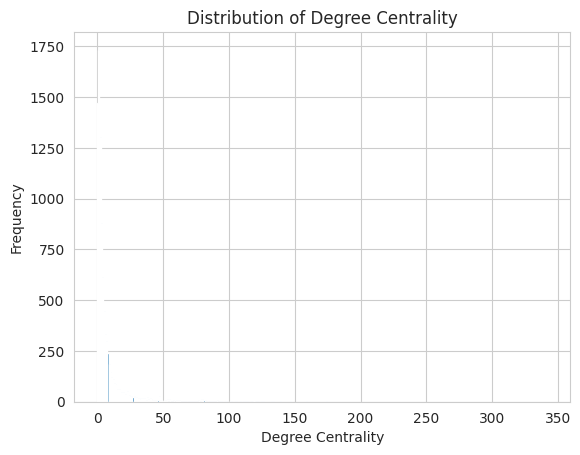

Detecting communities...
Running Clauset-Newman-Moore...
Running PLM community detection...
Converting node indices to names...


Processing eigenvector centrality: 100%|██████████| 9320/9320 [00:00<00:00, 1529019.53it/s]


Results:
Degree Centrality: [('Stanford University', 342.0), ('Tsinghua University', 274.0), ('Peking University', 263.0), ('University of Washington', 261.0), ('Harvard University', 245.0), ('University of Waterloo', 242.0), ('University of Toronto', 238.0), ('Johns Hopkins University', 230.0), ('University College London', 220.0), ('Yale University', 206.0)]
Closeness Centrality: [('Forschungsinstitut Betriebliche Bildung', 0.5), ('Leibniz Institute for Psychology', 0.5), ('R. G. Kar Medical College and Hospital', 0.5), ('College of Medicine & JNM Hospital', 0.5), ('Murshidabad Medical College and Hospital', 0.5), ('Amiri Hospital', 0.5), ('King Abdulaziz Medical City', 0.5), ('Georgia Canines for Independence', 0.5), ('Japan University of Economics', 0.5), ('Częstochowa University of Technology', 0.5)]
Betweenness Centrality: [('University College London', 0.021983798081060102), ('University of Waterloo', 0.020775093831685593), ('Yale University', 0.016754469886150834), ('Harvard U

In [ ]:
## Network analysis
# Calculate degree centrality (considering weights)
print("Calculating degree centrality...")
deg_centrality = nk.centrality.DegreeCentrality(projected_graph, ignoreSelfLoops=True)
deg_centrality.run()
degree_centrality_result = deg_centrality.ranking()

# Calculate closeness centrality for each connected component
print("Calculating closeness centrality...")
components = nk.components.ConnectedComponents(projected_graph).run()
closeness_centrality_result = []

for component in tqdm(components.getComponents(), desc="Processing components"):
    subgraph = nk.graphtools.subgraphFromNodes(projected_graph, component)
    closeness_centrality = nk.centrality.Closeness(subgraph, True, subgraph.upperNodeIdBound())
    closeness_centrality.run()
    closeness_centrality_result.extend(closeness_centrality.ranking())

# Sort the combined results
closeness_centrality_result.sort(key=lambda x: x[1], reverse=True)

# Calculate betweenness centrality
print("Calculating betweenness centrality...")
betweenness_centrality = nk.centrality.Betweenness(projected_graph, normalized=True)
betweenness_centrality.run()
betweenness_centrality_result = betweenness_centrality.ranking()

# Calculate eigenvector centrality
print("Calculating eigenvector centrality...")
eigenvector_centrality = nk.centrality.EigenvectorCentrality(projected_graph)
eigenvector_centrality.run()
eigenvector_centrality_result = eigenvector_centrality.ranking()

# Summarize the network
print("Calculating basic network metrics...")
num_nodes = projected_graph.numberOfNodes()
num_edges = projected_graph.numberOfEdges()
density = nk.graphtools.density(projected_graph)

# Extract largest connected component
largest_component = nk.components.ConnectedComponents.extractLargestConnectedComponent(projected_graph, True)

# Calculate diameter of the largest component
print("Calculating diameter...")
diam = nk.distance.Diameter(largest_component, algo=1)
diam.run()
diameter = diam.getDiameter()

# Calculate average shortest path length for the largest component
print("Calculating average shortest path length...")
apsp = nk.distance.APSP(largest_component).run()
distances = apsp.getDistances()

total_distance = 0
total_pairs = 0

for i, row in enumerate(tqdm(distances, desc="Processing distances")):
    for dist in row:
        if dist < float('inf'):
            total_distance += dist
            total_pairs += 1

avg_shortest_path_length = total_distance / total_pairs if total_pairs > 0 else float('inf')

# Calculate clustering coefficient
print("Calculating clustering coefficient...")
clustering_coefficient_result = nk.globals.clustering(projected_graph)

num_components = components.numberOfComponents()
largest_component_size = largest_component.numberOfNodes()

# Calculate the degree distribution
print("Calculating degree distribution...")
dc = nk.centrality.DegreeCentrality(projected_graph)
dc.run()
scores = dc.scores()

# Fit the degree distribution to a power law
print("Fitting power law...")
fit = powerlaw.Fit(scores)
power_law_value = fit.power_law.alpha

# Plot the degree distribution (optional)
degree_counts = {}
for score in tqdm(scores, desc="Computing degree counts"):
    if score in degree_counts:
        degree_counts[score] += 1
    else:
        degree_counts[score] = 1

plt.bar(degree_counts.keys(), degree_counts.values())
plt.xlabel('Degree Centrality')
plt.ylabel('Frequency')
plt.title('Distribution of Degree Centrality')
plt.show()

# Community detection
print("Detecting communities...")
print("Running Clauset-Newman-Moore...")
communities = greedy_modularity_communities(nx_projected_graph)
num_communities_nx = len(communities)

print("Running PLM community detection...")
community_detector = nk.community.PLM(projected_graph)
community_detector.run()
num_communities_nk = len(community_detector.getPartition().getSubsetIds())

# Convert indices back to node names for centrality measures
print("Converting node indices to names...")
reverse_institution_map = {v: k for k, v in institution_map.items()}
degree_centrality_named = [(reverse_institution_map[node], centrality) for node, centrality in tqdm(degree_centrality_result, desc="Processing degree centrality")]
closeness_centrality_named = [(reverse_institution_map[node], centrality) for node, centrality in tqdm(closeness_centrality_result, desc="Processing closeness centrality")]
betweenness_centrality_named = [(reverse_institution_map[node], centrality) for node, centrality in tqdm(betweenness_centrality_result, desc="Processing betweenness centrality")]
eigenvector_centrality_named = [(reverse_institution_map[node], centrality) for node, centrality in tqdm(eigenvector_centrality_result, desc="Processing eigenvector centrality")]

# Print results
print("\nResults:")
print("Degree Centrality:", degree_centrality_named[:10])  # Top 10 nodes
print("Closeness Centrality:", closeness_centrality_named[:10])  # Top 10 nodes
print("Betweenness Centrality:", betweenness_centrality_named[:10])  # Top 10 nodes
print("Eigenvector Centrality:", eigenvector_centrality_named[:10])  # Top 10 nodes

print("\nNetwork Statistics:")
print("Number of Nodes:", num_nodes)
print("Number of Edges:", num_edges)
print("Density:", density)
print("Diameter of Largest Component:", diameter)
print("Average Shortest Path Length:", avg_shortest_path_length)
print("Clustering Coefficient:", clustering_coefficient_result)
print("Number of Components:", num_components)
print("Size of Largest Component:", largest_component_size)
print("Power-law Exponent:", power_law_value)
print("Number of Communities (Networkit - PLM):", num_communities_nk)
print("Number of Communities (NetworkX - Clauset-Newman-Moore):", num_communities_nx)

In [ ]:
# Save the projected graph as a CSV file
edges = []
for u in range(projected_graph.numberOfNodes()):
    for v in projected_graph.iterNeighbors(u):
        weight = projected_graph.weight(u, v)
        edges.append([reverse_institution_map[u], reverse_institution_map[v], weight])

projected_institutions_edgelist = pd.DataFrame(edges, columns=['source', 'target', 'weight'])
projected_institutions_edgelist.to_csv('/content/drive/MyDrive/Project - LLM science of science/data_network/institutions_projected_edgelist.csv', index=False)

print("Projected graph saved as 'projected_graph.csv'.")

Projected graph saved as 'projected_graph.csv'.


In [ ]:
file_path = '/content/drive/MyDrive/Project - LLM science of science/data_network/institutions_projected_edgelist.csv'
projected_df = pd.read_csv(file_path)

# Create a weighted graph from the dataframe
G = nx.from_pandas_edgelist(projected_df, 'source', 'target', ['weight'])

# List of nodes directly connected to Harvard University
harvard_connected_nodes = list(G.neighbors('Harvard University'))
print('Institutions connected to Harvard University:')
print(harvard_connected_nodes)

# Analyze Harvard University as an intermediary
intermediary_connections = []

for node in harvard_connected_nodes:
    for connected_node in G.neighbors(node):
        if connected_node != 'Sta University' and connected_node not in harvard_connected_nodes:
            weight = G[node][connected_node]['weight'] if 'weight' in G[node][connected_node] else 1
            intermediary_connections.append((node, connected_node, weight))

# Count frequency of intermediary connections considering weights
intermediary_counter = Counter()
for node, connected_node, weight in intermediary_connections:
    intermediary_counter[(node, connected_node)] += weight

# Prepare the data for the CSV file
intermediary_data = [{'Connection': f'{connection[0]} - {connection[1]}', 'Frequency': freq} for connection, freq in intermediary_counter.items()]

# Create a DataFrame and save to CSV
intermediary_df = pd.DataFrame(intermediary_data)
intermediary_df.to_csv('harvard_intermediary_connections.csv', index=False)

Institutions connected to Harvard University:
['University of Minnesota Medical Center', 'University of Virginia', 'Research Network (United States)', 'Washington University in St. Louis', 'IBM (United States)', 'Medical University of South Carolina', 'Sejong University', 'Loyola University Chicago', 'UCSF Helen Diller Family Comprehensive Cancer Center', 'Boston Latin Academy', 'University of Massachusetts Chan Medical School', 'Texas A&M University', 'Medical University of Vienna', 'Metro Transit', 'Changsha University', 'Mbarara University of Science and Technology', 'Lemuel Shattuck Hospital', 'The University of Texas Southwestern Medical Center', 'Smith-Kettlewell Eye Research Institute', 'The University of Texas MD Anderson Cancer Center', 'Duke-NUS Medical School', 'University of British Columbia', 'MetroHealth', 'University of Sydney', 'University of the Philippines Manila', 'Pontificia Universidad Javeriana', 'Google (United States)', 'Complejo Asistencial Universitario de Pal

In [ ]:
file_path = '/content/drive/MyDrive/Project - LLM science of science/data_network/institutions_projected_edgelist.csv'
projected_df = pd.read_csv(file_path)

# Create a weighted graph from the dataframe
G = nx.from_pandas_edgelist(projected_df, 'source', 'target', ['weight'])

# List of nodes directly connected to University College London
UCL_connected_nodes = list(G.neighbors('University College London'))
print('Institutions connected to University College London:')
print(UCL_connected_nodes)

# Analyze University College London as an intermediary
intermediary_connections = []

for node in UCL_connected_nodes:
    for connected_node in G.neighbors(node):
        if connected_node != 'University College London' and connected_node not in UCL_connected_nodes:
            weight = G[node][connected_node]['weight'] if 'weight' in G[node][connected_node] else 1
            intermediary_connections.append((node, connected_node, weight))

# Count frequency of intermediary connections considering weights
intermediary_counter = Counter()
for node, connected_node, weight in intermediary_connections:
    intermediary_counter[(node, connected_node)] += weight

# Prepare the data for the CSV file
intermediary_data = [{'Connection': f'{connection[0]} - {connection[1]}', 'Frequency': freq} for connection, freq in intermediary_counter.items()]

# Create a DataFrame and save to CSV
intermediary_df = pd.DataFrame(intermediary_data)
intermediary_df.to_csv('UCL_intermediary_connections.csv', index=False)

Institutions connected to University College London:
['Johannes Gutenberg University Mainz', 'Mercy University Hospital', 'University of Salerno', 'LifeArc', 'Tianjin Foreign Studies University', 'Systemic Risk Centre', 'Tilburg University', 'Nnamdi Azikiwe University', 'Leverhulme Trust', 'National Research Council Canada', 'University of St. Gallen', 'University Hospital Lewisham', 'Tsinghua University', 'National Yang Ming Chiao Tung University', 'Sichuan University', 'University Ferhat Abbas of Setif', 'Binghamton University', 'Mohamed bin Zayed University of Artificial Intelligence', 'University of Sydney', 'University Malaya Medical Centre', 'American Medical Association', 'Chinese University of Hong Kong', 'University of Shanghai for Science and Technology', 'Google (United States)', 'Microsoft Research Asia (China)', 'Zhejiang Lab', 'Huazhong University of Science and Technology', 'Uppsala University', 'Sony Corporation (United States)', 'Shanghai Eighth People Hospital', 'Biel

### by Countries

In [ ]:
# Load the data from the file
file_path = '/content/drive/MyDrive/Project - LLM science of science/updated_dataset/llm-information-entropy.csv'
df = pd.read_csv(file_path)

# Affiliation_countries is in a list format
df['affiliation_countries'] = df['country_codes'].apply(eval)

# Create an edgelist
edgelist = []
for index, row in df.iterrows():
    title = row['title']
    countries = row['affiliation_countries']
    for countries in countries:
        edgelist.append((title, countries))

# Convert the edgelist to a DataFrame
edgelist_df = pd.DataFrame(edgelist, columns=['source', 'target'])

# Save the edgelist to a CSV file
edgelist_df.to_csv('/content/drive/MyDrive/Project - LLM science of science/data_network/affiliation_countries_entropy_edgelist.csv', index=False)

print("Edgelist created and saved as 'edgelist.csv'.")

Edgelist created and saved as 'edgelist.csv'.


In [ ]:
# Map nodes to indices
node_map = {}
index = 0

def get_node_index(node):
    global index
    if node not in node_map:
        node_map[node] = index
        index += 1
    return node_map[node]

# Determine the number of unique nodes
num_nodes = len(set(edgelist_df['source']).union(set(edgelist_df['target'])))

# Create a bipartite graph with the predefined number of nodes
B = nk.graph.Graph(num_nodes, weighted=True, directed=False)

# Add edges to the bipartite graph
for _, row in edgelist_df.iterrows():
    paper = get_node_index(row['source'])
    countries = get_node_index(row['target'])
    B.addEdge(paper, countries)

In [ ]:
# Collect country
countries = set()
for _, row in tqdm(edgelist_df.iterrows(), desc="Collecting country", total=len(edgelist_df)):
    countries.add(row['target'])

# Create a projection onto country
projected_graph = nk.graph.Graph(len(countries), weighted=True, directed=False)

# Map country to indices in the projected graph
country_map = {disc: i for i, disc in enumerate(countries)}

# Initialize a dictionary to hold the edge weights
edge_weights = {}

# Add edges between country that share at least one paper, with weights
for _, row in tqdm(edgelist_df.iterrows(), desc="Building edge weights", total=len(edgelist_df)):
    paper = get_node_index(row['source'])
    country = country_map[row['target']]
    for neighbor in B.iterNeighbors(paper):
        neighbor_country = None
        for key, value in node_map.items():
            if value == neighbor:
                if key in countries:
                    neighbor_country = country_map[key]
                    break
        if neighbor_country is not None and neighbor_country != country:
            if (country, neighbor_country) in edge_weights:
                edge_weights[(country, neighbor_country)] += 1
            elif (neighbor_country, country) in edge_weights:
                edge_weights[(neighbor_country, country)] += 1
            else:
                edge_weights[(country, neighbor_country)] = 1

# Add edges with weights to the projected graph
for (u, v), weight in tqdm(edge_weights.items(), desc="Adding weighted edges", total=len(edge_weights)):
    projected_graph.addEdge(u, v, weight)

Adding weighted edges: 100%|██████████| 1805/1805 [00:00<00:00, 651132.60it/s]


In [ ]:
# Convert Networkit graph to NetworkX graph
def networkit_to_networkx(nk_graph):
    nx_graph = nx.Graph()
    for u in nk_graph.iterNodes():
        nx_graph.add_node(u)
    for u, v in nk_graph.iterEdges():
        nx_graph.add_edge(u, v, weight=nk_graph.weight(u, v))
    return nx_graph

# Create projected graph
projected_graph = nk.graph.Graph(len(countries), weighted=True, directed=False)
for (u, v), weight in edge_weights.items():
    projected_graph.addEdge(u, v, weight)

# Convert projected graph to NetworkX graph
nx_projected_graph = networkit_to_networkx(projected_graph)

Calculating degree centrality...
Calculating closeness centrality...


Processing components: 100%|██████████| 17/17 [00:00<00:00, 2930.91it/s]


Calculating betweenness centrality...
Calculating eigenvector centrality...
Calculating basic network metrics...
Calculating diameter...
Calculating average shortest path length...


Processing distances: 100%|██████████| 143/143 [00:00<00:00, 17400.72it/s]
Values less than or equal to 0 in data. Throwing out 0 or negative values


Calculating clustering coefficient...
Calculating degree distribution...
Fitting power law...
Calculating best minimal value for power law fit


Computing degree counts: 100%|██████████| 159/159 [00:00<00:00, 790159.17it/s]


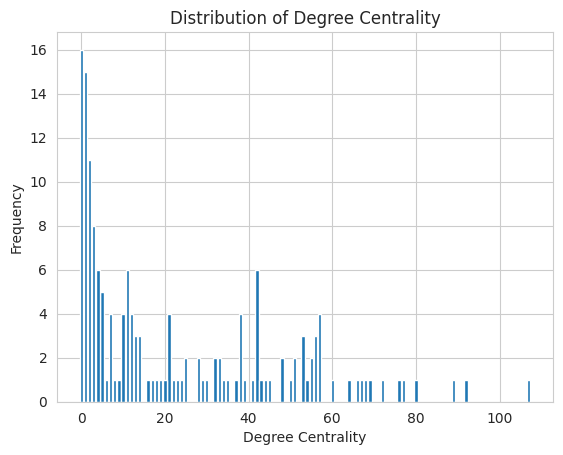

Detecting communities...
Running Clauset-Newman-Moore...
Running PLM community detection...
Converting node indices to names...


Processing eigenvector centrality: 100%|██████████| 159/159 [00:00<00:00, 958181.52it/s]


Results:
Degree Centrality: [('US', 107.0), ('GB', 92.0), ('CN', 89.0), ('IN', 80.0), ('CA', 77.0), ('AU', 76.0), ('DE', 72.0), ('ES', 69.0), ('IT', 68.0), ('MY', 67.0)]
Closeness Centrality: [('ET', 0.16985645933014354), ('PL', 0.16864608076009502), ('BR', 0.1658878504672897), ('QA', 0.16511627906976745), ('MX', 0.16397228637413394), ('EG', 0.16284403669724773), ('ZA', 0.16247139588100687), ('PH', 0.16173120728929385), ('PT', 0.16173120728929385), ('CZ', 0.16063348416289594)]
Betweenness Centrality: [('PL', 0.06512201003139276), ('US', 0.055845733395093064), ('BR', 0.04900531170086172), ('IN', 0.04880713306597087), ('GB', 0.04169414539195727), ('ET', 0.0408609185259586), ('PH', 0.040228280435310404), ('SE', 0.04011085237764742), ('ES', 0.03707906585203769), ('MX', 0.036099591661979964)]
Eigenvector Centrality: [('US', 0.6103713696487436), ('CN', 0.5237583741497794), ('GB', 0.3739689316642689), ('CA', 0.19232326731114174), ('SG', 0.19198817496397116), ('DE', 0.18208416637176797), ('AU

In [ ]:
## Network analysis
# Calculate degree centrality (considering weights)
print("Calculating degree centrality...")
deg_centrality = nk.centrality.DegreeCentrality(projected_graph, ignoreSelfLoops=True)
deg_centrality.run()
degree_centrality_result = deg_centrality.ranking()

# Calculate closeness centrality for each connected component
print("Calculating closeness centrality...")
components = nk.components.ConnectedComponents(projected_graph).run()
closeness_centrality_result = []

for component in tqdm(components.getComponents(), desc="Processing components"):
    subgraph = nk.graphtools.subgraphFromNodes(projected_graph, component)
    closeness_centrality = nk.centrality.Closeness(subgraph, True, subgraph.upperNodeIdBound())
    closeness_centrality.run()
    closeness_centrality_result.extend(closeness_centrality.ranking())

# Sort the combined results
closeness_centrality_result.sort(key=lambda x: x[1], reverse=True)

# Calculate betweenness centrality
print("Calculating betweenness centrality...")
betweenness_centrality = nk.centrality.Betweenness(projected_graph, normalized=True)
betweenness_centrality.run()
betweenness_centrality_result = betweenness_centrality.ranking()

# Calculate eigenvector centrality
print("Calculating eigenvector centrality...")
eigenvector_centrality = nk.centrality.EigenvectorCentrality(projected_graph)
eigenvector_centrality.run()
eigenvector_centrality_result = eigenvector_centrality.ranking()

# Summarize the network
print("Calculating basic network metrics...")
num_nodes = projected_graph.numberOfNodes()
num_edges = projected_graph.numberOfEdges()
density = nk.graphtools.density(projected_graph)

# Extract largest connected component
largest_component = nk.components.ConnectedComponents.extractLargestConnectedComponent(projected_graph, True)

# Calculate diameter of the largest component
print("Calculating diameter...")
diam = nk.distance.Diameter(largest_component, algo=1)
diam.run()
diameter = diam.getDiameter()

# Calculate average shortest path length for the largest component
print("Calculating average shortest path length...")
apsp = nk.distance.APSP(largest_component).run()
distances = apsp.getDistances()

total_distance = 0
total_pairs = 0

for i, row in enumerate(tqdm(distances, desc="Processing distances")):
    for dist in row:
        if dist < float('inf'):
            total_distance += dist
            total_pairs += 1

avg_shortest_path_length = total_distance / total_pairs if total_pairs > 0 else float('inf')

# Calculate clustering coefficient
print("Calculating clustering coefficient...")
clustering_coefficient_result = nk.globals.clustering(projected_graph)

num_components = components.numberOfComponents()
largest_component_size = largest_component.numberOfNodes()

# Calculate the degree distribution
print("Calculating degree distribution...")
dc = nk.centrality.DegreeCentrality(projected_graph)
dc.run()
scores = dc.scores()

# Fit the degree distribution to a power law
print("Fitting power law...")
fit = powerlaw.Fit(scores)
power_law_value = fit.power_law.alpha

# Plot the degree distribution (optional)
degree_counts = {}
for score in tqdm(scores, desc="Computing degree counts"):
    if score in degree_counts:
        degree_counts[score] += 1
    else:
        degree_counts[score] = 1

plt.bar(degree_counts.keys(), degree_counts.values())
plt.xlabel('Degree Centrality')
plt.ylabel('Frequency')
plt.title('Distribution of Degree Centrality')
plt.show()

# Community detection
print("Detecting communities...")
print("Running Clauset-Newman-Moore...")
communities = greedy_modularity_communities(nx_projected_graph)
num_communities_nx = len(communities)

print("Running PLM community detection...")
community_detector = nk.community.PLM(projected_graph)
community_detector.run()
num_communities_nk = len(community_detector.getPartition().getSubsetIds())

# Convert indices back to node names for centrality measures
print("Converting node indices to names...")
reverse_country_map = {v: k for k, v in country_map.items()}
degree_centrality_named = [(reverse_country_map[node], centrality) for node, centrality in tqdm(degree_centrality_result, desc="Processing degree centrality")]
closeness_centrality_named = [(reverse_country_map[node], centrality) for node, centrality in tqdm(closeness_centrality_result, desc="Processing closeness centrality")]
betweenness_centrality_named = [(reverse_country_map[node], centrality) for node, centrality in tqdm(betweenness_centrality_result, desc="Processing betweenness centrality")]
eigenvector_centrality_named = [(reverse_country_map[node], centrality) for node, centrality in tqdm(eigenvector_centrality_result, desc="Processing eigenvector centrality")]

# Print results
print("\nResults:")
print("Degree Centrality:", degree_centrality_named[:10])  # Top 10 nodes
print("Closeness Centrality:", closeness_centrality_named[:10])  # Top 10 nodes
print("Betweenness Centrality:", betweenness_centrality_named[:10])  # Top 10 nodes
print("Eigenvector Centrality:", eigenvector_centrality_named[:10])  # Top 10 nodes

print("\nNetwork Statistics:")
print("Number of Nodes:", num_nodes)
print("Number of Edges:", num_edges)
print("Density:", density)
print("Diameter of Largest Component:", diameter)
print("Average Shortest Path Length:", avg_shortest_path_length)
print("Clustering Coefficient:", clustering_coefficient_result)
print("Number of Components:", num_components)
print("Size of Largest Component:", largest_component_size)
print("Power-law Exponent:", power_law_value)
print("Number of Communities (Networkit - PLM):", num_communities_nk)
print("Number of Communities (NetworkX - Clauset-Newman-Moore):", num_communities_nx)

In [ ]:
# Save the projected graph as a CSV file
edges = []
for u in range(projected_graph.numberOfNodes()):
    for v in projected_graph.iterNeighbors(u):
        weight = projected_graph.weight(u, v)
        edges.append([reverse_country_map[u], reverse_country_map[v], weight])

projected_country_edgelist = pd.DataFrame(edges, columns=['source', 'target', 'weight'])
projected_country_edgelist.to_csv('/content/drive/MyDrive/Project - LLM science of science/data_network/countries_projected_edgelist.csv', index=False)

print("Projected graph saved as 'projected_graph.csv'.")

Projected graph saved as 'projected_graph.csv'.


# CONTROL GROUP - ML papers

### by Disciplines

In [ ]:
# Load the data from the file
file_path = '/content/drive/MyDrive/Project - LLM science of science/updated_dataset/ml-information-entropy.csv'
df = pd.read_csv(file_path)

# Affiliation_disciplines is in a list format
df['affiliation_disciplines'] = df['departments'].apply(eval)

# Create an edgelist
edgelist = []
for index, row in df.iterrows():
    title = row['title']
    disciplines = row['affiliation_disciplines']
    for discipline in disciplines:
        edgelist.append((title, discipline))

# Convert the edgelist to a DataFrame
edgelist_df = pd.DataFrame(edgelist, columns=['source', 'target'])

# Save the edgelist to a CSV file
edgelist_df.to_csv('/content/drive/MyDrive/Project - LLM science of science/data_network/MLpapers_disciplines_entropy_edgelist.csv', index=False)

print("Edgelist created and saved as 'edgelist.csv'.")

Edgelist created and saved as 'edgelist.csv'.


In [ ]:
# Map nodes to indices
node_map = {}
index = 0

def get_node_index(node):
    global index
    if node not in node_map:
        node_map[node] = index
        index += 1
    return node_map[node]

# Determine the number of unique nodes
num_nodes = len(set(edgelist_df['source']).union(set(edgelist_df['target'])))

# Create a bipartite graph with the predefined number of nodes
B = nk.graph.Graph(num_nodes, weighted=True, directed=False)

# Add edges to the bipartite graph
for _, row in edgelist_df.iterrows():
    paper = get_node_index(row['source'])
    discipline = get_node_index(row['target'])
    B.addEdge(paper, discipline)

In [ ]:
# Collect disciplines
disciplines = set()
for _, row in tqdm(edgelist_df.iterrows(), desc="Collecting disciplines", total=len(edgelist_df)):
    disciplines.add(row['target'])

# Create a projection onto disciplines
projected_graph = nk.graph.Graph(len(disciplines), weighted=True, directed=False)

# Map disciplines to indices in the projected graph
discipline_map = {disc: i for i, disc in enumerate(disciplines)}

# Initialize a dictionary to hold the edge weights
edge_weights = {}

# Add edges between disciplines that share at least one paper, with weights
for _, row in tqdm(edgelist_df.iterrows(), desc="Building edge weights", total=len(edgelist_df)):
    paper = get_node_index(row['source'])
    discipline = discipline_map[row['target']]
    for neighbor in B.iterNeighbors(paper):
        neighbor_discipline = None
        for key, value in node_map.items():
            if value == neighbor:
                if key in disciplines:
                    neighbor_discipline = discipline_map[key]
                    break
        if neighbor_discipline is not None and neighbor_discipline != discipline:
            if (discipline, neighbor_discipline) in edge_weights:
                edge_weights[(discipline, neighbor_discipline)] += 1
            elif (neighbor_discipline, discipline) in edge_weights:
                edge_weights[(neighbor_discipline, discipline)] += 1
            else:
                edge_weights[(discipline, neighbor_discipline)] = 1

# Add edges with weights to the projected graph
for (u, v), weight in tqdm(edge_weights.items(), desc="Adding weighted edges", total=len(edge_weights)):
    projected_graph.addEdge(u, v, weight)

Adding weighted edges: 100%|██████████| 121854/121854 [00:00<00:00, 1366616.54it/s]


In [ ]:
# Convert Networkit graph to NetworkX graph
def networkit_to_networkx(nk_graph):
    nx_graph = nx.Graph()
    for u in nk_graph.iterNodes():
        nx_graph.add_node(u)
    for u, v in nk_graph.iterEdges():
        nx_graph.add_edge(u, v, weight=nk_graph.weight(u, v))
    return nx_graph

# Create projected graph
projected_graph = nk.graph.Graph(len(disciplines), weighted=True, directed=False)
for (u, v), weight in edge_weights.items():
    projected_graph.addEdge(u, v, weight)

# Convert projected graph to NetworkX graph
nx_projected_graph = networkit_to_networkx(projected_graph)

Calculating degree centrality...
Calculating closeness centrality...


Processing components: 100%|██████████| 2786/2786 [00:29<00:00, 93.27it/s] 


Calculating betweenness centrality...
Calculating eigenvector centrality...
Calculating basic network metrics...
Calculating diameter...
Calculating average shortest path length...


Processing distances: 100%|██████████| 21261/21261 [02:16<00:00, 156.08it/s]
Values less than or equal to 0 in data. Throwing out 0 or negative values


Calculating clustering coefficient...
Calculating degree distribution...
Fitting power law...
Calculating best minimal value for power law fit


Computing degree counts: 100%|██████████| 24707/24707 [00:00<00:00, 1756001.44it/s]


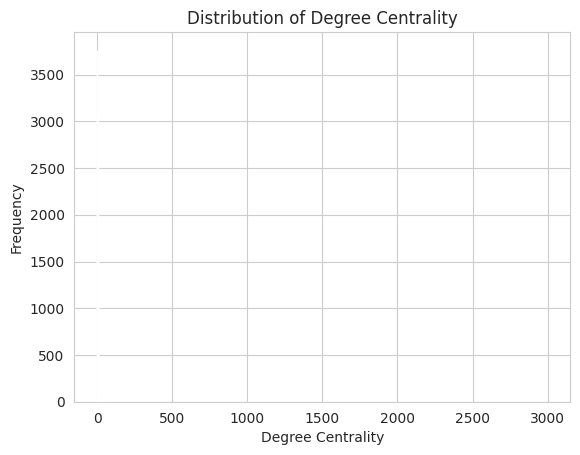

Detecting communities...
Running Clauset-Newman-Moore...
Running PLM community detection...
Converting node indices to names...


Processing eigenvector centrality: 100%|██████████| 24707/24707 [00:00<00:00, 1487507.09it/s]


Results:
Degree Centrality: [('Computer Science', 3001.0), ('Medicine', 2184.0), ('Engineering', 1501.0), ('Physics', 1240.0), ('Computer Science and Engineering', 1201.0), ('Biomedical Engineering', 1162.0), ('Mechanical Engineering', 1156.0), ('Radiology', 1094.0), ('Neurology', 1093.0), ('Electrical Engineering', 994.0)]
Closeness Centrality: [('Innovation and Society', 0.5), ('Innovation in Society', 0.5), ('Responsible Innovation', 0.5), ('European Studies', 0.5), ('Political Science and International Relations', 0.5), ('Maritime Transportation Safety', 0.5), ('Navigation Convergence Studies', 0.5), ('Computer Science, Electrical and Computer Engineering, Statistical Science', 0.5), ('Computation for Society', 0.5), ('Jewelry and Art Design', 0.5)]
Betweenness Centrality: [('Computer Science', 0.07613373600593956), ('Engineering', 0.04288533519908251), ('Medicine', 0.03715388471885728), ('Mechanical Engineering', 0.029836729924963352), ('Physics', 0.02731791904628156), ('Electric

In [ ]:
## Network analysis
# Calculate degree centrality (considering weights)
print("Calculating degree centrality...")
deg_centrality = nk.centrality.DegreeCentrality(projected_graph, ignoreSelfLoops=True)
deg_centrality.run()
degree_centrality_result = deg_centrality.ranking()

# Calculate closeness centrality for each connected component
print("Calculating closeness centrality...")
components = nk.components.ConnectedComponents(projected_graph).run()
closeness_centrality_result = []

for component in tqdm(components.getComponents(), desc="Processing components"):
    subgraph = nk.graphtools.subgraphFromNodes(projected_graph, component)
    closeness_centrality = nk.centrality.Closeness(subgraph, True, subgraph.upperNodeIdBound())
    closeness_centrality.run()
    closeness_centrality_result.extend(closeness_centrality.ranking())

# Sort the combined results
closeness_centrality_result.sort(key=lambda x: x[1], reverse=True)

# Calculate betweenness centrality
print("Calculating betweenness centrality...")
betweenness_centrality = nk.centrality.Betweenness(projected_graph, normalized=True)
betweenness_centrality.run()
betweenness_centrality_result = betweenness_centrality.ranking()

# Calculate eigenvector centrality
print("Calculating eigenvector centrality...")
eigenvector_centrality = nk.centrality.EigenvectorCentrality(projected_graph)
eigenvector_centrality.run()
eigenvector_centrality_result = eigenvector_centrality.ranking()

# Summarize the network
print("Calculating basic network metrics...")
num_nodes = projected_graph.numberOfNodes()
num_edges = projected_graph.numberOfEdges()
density = nk.graphtools.density(projected_graph)

# Extract largest connected component
largest_component = nk.components.ConnectedComponents.extractLargestConnectedComponent(projected_graph, True)

# Calculate diameter of the largest component
print("Calculating diameter...")
diam = nk.distance.Diameter(largest_component, algo=1)
diam.run()
diameter = diam.getDiameter()

# Calculate average shortest path length for the largest component
print("Calculating average shortest path length...")
apsp = nk.distance.APSP(largest_component).run()
distances = apsp.getDistances()

total_distance = 0
total_pairs = 0

for i, row in enumerate(tqdm(distances, desc="Processing distances")):
    for dist in row:
        if dist < float('inf'):
            total_distance += dist
            total_pairs += 1

avg_shortest_path_length = total_distance / total_pairs if total_pairs > 0 else float('inf')

# Calculate clustering coefficient
print("Calculating clustering coefficient...")
clustering_coefficient_result = nk.globals.clustering(projected_graph)

num_components = components.numberOfComponents()
largest_component_size = largest_component.numberOfNodes()

# Calculate the degree distribution
print("Calculating degree distribution...")
dc = nk.centrality.DegreeCentrality(projected_graph)
dc.run()
scores = dc.scores()

# Fit the degree distribution to a power law
print("Fitting power law...")
fit = powerlaw.Fit(scores)
power_law_value = fit.power_law.alpha

# Plot the degree distribution (optional)
degree_counts = {}
for score in tqdm(scores, desc="Computing degree counts"):
    if score in degree_counts:
        degree_counts[score] += 1
    else:
        degree_counts[score] = 1

plt.bar(degree_counts.keys(), degree_counts.values())
plt.xlabel('Degree Centrality')
plt.ylabel('Frequency')
plt.title('Distribution of Degree Centrality')
plt.show()

# Community detection
print("Detecting communities...")
print("Running Clauset-Newman-Moore...")
communities = greedy_modularity_communities(nx_projected_graph)
num_communities_nx = len(communities)

print("Running PLM community detection...")
community_detector = nk.community.PLM(projected_graph)
community_detector.run()
num_communities_nk = len(community_detector.getPartition().getSubsetIds())

# Convert indices back to node names for centrality measures
print("Converting node indices to names...")
reverse_discipline_map = {v: k for k, v in discipline_map.items()}
degree_centrality_named = [(reverse_discipline_map[node], centrality) for node, centrality in tqdm(degree_centrality_result, desc="Processing degree centrality")]
closeness_centrality_named = [(reverse_discipline_map[node], centrality) for node, centrality in tqdm(closeness_centrality_result, desc="Processing closeness centrality")]
betweenness_centrality_named = [(reverse_discipline_map[node], centrality) for node, centrality in tqdm(betweenness_centrality_result, desc="Processing betweenness centrality")]
eigenvector_centrality_named = [(reverse_discipline_map[node], centrality) for node, centrality in tqdm(eigenvector_centrality_result, desc="Processing eigenvector centrality")]

# Print results
print("\nResults:")
print("Degree Centrality:", degree_centrality_named[:10])  # Top 10 nodes
print("Closeness Centrality:", closeness_centrality_named[:10])  # Top 10 nodes
print("Betweenness Centrality:", betweenness_centrality_named[:10])  # Top 10 nodes
print("Eigenvector Centrality:", eigenvector_centrality_named[:10])  # Top 10 nodes

print("\nNetwork Statistics:")
print("Number of Nodes:", num_nodes)
print("Number of Edges:", num_edges)
print("Density:", density)
print("Diameter of Largest Component:", diameter)
print("Average Shortest Path Length:", avg_shortest_path_length)
print("Clustering Coefficient:", clustering_coefficient_result)
print("Number of Components:", num_components)
print("Size of Largest Component:", largest_component_size)
print("Power-law Exponent:", power_law_value)
print("Number of Communities (Networkit - PLM):", num_communities_nk)
print("Number of Communities (NetworkX - Clauset-Newman-Moore):", num_communities_nx)

In [ ]:
# Save the projected graph as a CSV file
edges = []
for u in range(projected_graph.numberOfNodes()):
    for v in projected_graph.iterNeighbors(u):
        weight = projected_graph.weight(u, v)
        edges.append([reverse_discipline_map[u], reverse_discipline_map[v], weight])

projected_disciplines_edgelist = pd.DataFrame(edges, columns=['source', 'target', 'weight'])
projected_disciplines_edgelist.to_csv('/content/drive/MyDrive/Project - LLM science of science/data_network/MLpapers_disciplines_projected_edgelist.csv', index=False)

print("Projected graph saved as 'projected_graph.csv'.")

Projected graph saved as 'projected_graph.csv'.


In [ ]:
file_path = '/content/drive/MyDrive/Project - LLM science of science/data_network/disciplines_projected_edgelist.csv'
projected_df = pd.read_csv(file_path)

# Create a weighted graph from the dataframe
G = nx.from_pandas_edgelist(projected_df, 'source', 'target', ['weight'])

# List of nodes directly connected to Computer Science
CS_connected_nodes = list(G.neighbors('Computer Science'))
print('Disciplines connected to Computer Science:')
print(CS_connected_nodes)

# Analyze Computer Science as an intermediary
intermediary_connections = []

for node in CS_connected_nodes:
    for connected_node in G.neighbors(node):
        if connected_node != 'Computer Science' and connected_node not in CS_connected_nodes:
            weight = G[node][connected_node]['weight'] if 'weight' in G[node][connected_node] else 1
            intermediary_connections.append((node, connected_node, weight))

# Count frequency of intermediary connections considering weights
intermediary_counter = Counter()
for node, connected_node, weight in intermediary_connections:
    intermediary_counter[(node, connected_node)] += weight

# Prepare the data for the CSV file
intermediary_data = [{'Connection': f'{connection[0]} - {connection[1]}', 'Frequency': freq} for connection, freq in intermediary_counter.items()]

# Create a DataFrame and save to CSV
intermediary_df = pd.DataFrame(intermediary_data)
intermediary_df.to_csv('CS_intermediary_connections.csv', index=False)

Disciplines connected to Computer Science:
['Neurology', 'Geospatial Data Science', 'English', 'Computer Science & Information Engineering', 'Chemistry', 'Natural Language Processing', 'Chinese Information Processing', 'Scientific Research', 'Pathology and Immunology', 'Interaction', 'Chemical Technology', 'Electronic and Computer Engineering', 'Telecommunication Systems Management', 'AI Lab', 'Health Information', 'Natural Sciences', 'Social Science and Humanities', 'Economic Sciences', 'Electronic and Communications Engineering', 'Human Language Technology', 'Cognitive Science', 'Information and Physical Sciences', 'Finance & Economics', 'Advanced Research Computing', 'Information Technology Application Innovation', 'Information and Electronics', 'Computer Vision', 'Anesthesiology and Pain Medicine', 'General Surgery', 'Contents Research', 'Geography and Environment', 'Cultural Sciences', 'Prosthodontics', 'Bio-Med Big Data', 'Epidemiology and Population Health', 'Computing and Commu

In [ ]:
file_path = '/content/drive/MyDrive/Project - LLM science of science/data_network/disciplines_projected_edgelist.csv'
projected_df = pd.read_csv(file_path)

# Create a weighted graph from the dataframe
G = nx.from_pandas_edgelist(projected_df, 'source', 'target', ['weight'])

# List of nodes directly connected to Medicine
MEDICINE_connected_nodes = list(G.neighbors('Medicine'))
print('Disciplines connected to Medicine:')
print(MEDICINE_connected_nodes)

# Analyze Medicine as an intermediary
intermediary_connections = []

for node in MEDICINE_connected_nodes:
    for connected_node in G.neighbors(node):
        if connected_node != 'Medicine' and connected_node not in MEDICINE_connected_nodes:
            weight = G[node][connected_node]['weight'] if 'weight' in G[node][connected_node] else 1
            intermediary_connections.append((node, connected_node, weight))

# Count frequency of intermediary connections considering weights
intermediary_counter = Counter()
for node, connected_node, weight in intermediary_connections:
    intermediary_counter[(node, connected_node)] += weight

# Prepare the data for the MEDICINEV file
intermediary_data = [{'Connection': f'{connection[0]} - {connection[1]}', 'Frequency': freq} for connection, freq in intermediary_counter.items()]

# Create a DataFrame and save to MEDICINEV
intermediary_df = pd.DataFrame(intermediary_data)
intermediary_df.to_csv('MEDICINE_intermediary_connections.csv', index=False)

Disciplines connected to Medicine:
['Neurology', 'Artificial Intelligence in Healthcare', 'Cognitive and Brain Sciences', 'Chemistry', 'Natural Language Processing', 'Pathology and Immunology', 'Behavioral Health and Technology', "Men's Health: Aging and Metabolism", 'Clinical Cell Therapy', 'Physiotherapy', 'Health Information', 'Health Care Policy and Research', 'Data-Driven Insights and Innovation', 'Anesthesiology and Pharmacology', 'Computational Precision Health', 'Math and Computer', 'Surgical Outcomes Research', 'General Surgery', 'Plastic surgeon', 'Epidemiology and Population Health', 'Epidemiology', 'Child and Adolescent Psychiatry', 'Health Research Methods', 'Future Studies', 'Applied Science', 'Public Health and Human Sciences', 'Industrial Engineering and Engineering Management', 'Human Performance, Health Informatics and Information Management', 'Biomedical Informatics Research', 'Biomedical', 'Otolaryngology-Head and Neck Surgery', 'Health Policy and Administration', '

In [ ]:
### calculate the intermediaries (the facilitators of LLMs research)

In [ ]:
print(projected_graph.numberOfNodes(), projected_graph.numberOfEdges())

6604 16811


### by Institutions


In [ ]:
# Load the data from the file
file_path = '/content/drive/MyDrive/Project - LLM science of science/updated_dataset/ml-information-entropy.csv'
df = pd.read_csv(file_path)

# Affiliation_institutions is in a list format
df['affiliation_institutions'] = df['institutions'].apply(eval)

# Create an edgelist
edgelist = []
for index, row in df.iterrows():
    title = row['title']
    institutions = row['affiliation_institutions']
    for institution in institutions:
        edgelist.append((title, institution))

# Convert the edgelist to a DataFrame
edgelist_df = pd.DataFrame(edgelist, columns=['source', 'target'])

# Save the edgelist to a CSV file
edgelist_df.to_csv('/content/drive/MyDrive/Project - LLM science of science/data_network/MLpapers_institutions_entropy_edgelist.csv', index=False)

print("Edgelist created and saved as 'edgelist.csv'.")

Edgelist created and saved as 'edgelist.csv'.


In [ ]:
# Map nodes to indices
node_map = {}
index = 0

def get_node_index(node):
    global index
    if node not in node_map:
        node_map[node] = index
        index += 1
    return node_map[node]

# Determine the number of unique nodes
num_nodes = len(set(edgelist_df['source']).union(set(edgelist_df['target'])))

# Create a bipartite graph with the predefined number of nodes
B = nk.graph.Graph(num_nodes, weighted=True, directed=False)

# Add edges to the bipartite graph
for _, row in edgelist_df.iterrows():
    paper = get_node_index(row['source'])
    institution = get_node_index(row['target'])
    B.addEdge(paper, institution)

In [ ]:
# Collect institutions
institutions = set()
for _, row in tqdm(edgelist_df.iterrows(), desc="Collecting institutions", total=len(edgelist_df)):
    institutions.add(row['target'])

# Create a projection onto institutions
projected_graph = nk.graph.Graph(len(institutions), weighted=True, directed=False)

# Map institutions to indices in the projected graph
institution_map = {disc: i for i, disc in enumerate(institutions)}

# Initialize a dictionary to hold the edge weights
edge_weights = {}

# Add edges between institutions that share at least one paper, with weights
for _, row in tqdm(edgelist_df.iterrows(), desc="Building edge weights", total=len(edgelist_df)):
    paper = get_node_index(row['source'])
    institution = institution_map[row['target']]
    for neighbor in B.iterNeighbors(paper):
        neighbor_institution = None
        for key, value in node_map.items():
            if value == neighbor:
                if key in institutions:
                    neighbor_institution = institution_map[key]
                    break
        if neighbor_institution is not None and neighbor_institution != institution:
            if (institution, neighbor_institution) in edge_weights:
                edge_weights[(institution, neighbor_institution)] += 1
            elif (neighbor_institution, institution) in edge_weights:
                edge_weights[(neighbor_institution, institution)] += 1
            else:
                edge_weights[(institution, neighbor_institution)] = 1

# Add edges with weights to the projected graph
for (u, v), weight in tqdm(edge_weights.items(), desc="Adding weighted edges", total=len(edge_weights)):
    projected_graph.addEdge(u, v, weight)

Adding weighted edges: 100%|██████████| 119960/119960 [00:00<00:00, 1361834.19it/s]


In [ ]:
# Convert Networkit graph to NetworkX graph
def networkit_to_networkx(nk_graph):
    nx_graph = nx.Graph()
    for u in nk_graph.iterNodes():
        nx_graph.add_node(u)
    for u, v in nk_graph.iterEdges():
        nx_graph.add_edge(u, v, weight=nk_graph.weight(u, v))
    return nx_graph

# Create projected graph
projected_graph = nk.graph.Graph(len(institutions), weighted=True, directed=False)
for (u, v), weight in edge_weights.items():
    projected_graph.addEdge(u, v, weight)

# Convert projected graph to NetworkX graph
nx_projected_graph = networkit_to_networkx(projected_graph)

Calculating degree centrality...
Calculating closeness centrality...


Processing components: 100%|██████████| 1481/1481 [00:15<00:00, 95.64it/s] 


Calculating betweenness centrality...
Calculating eigenvector centrality...
Calculating basic network metrics...
Calculating diameter...
Calculating average shortest path length...


Processing distances: 100%|██████████| 14699/14699 [01:07<00:00, 216.34it/s]
Values less than or equal to 0 in data. Throwing out 0 or negative values


Calculating clustering coefficient...
Calculating degree distribution...
Fitting power law...
Calculating best minimal value for power law fit


Computing degree counts: 100%|██████████| 16391/16391 [00:00<00:00, 1701072.30it/s]


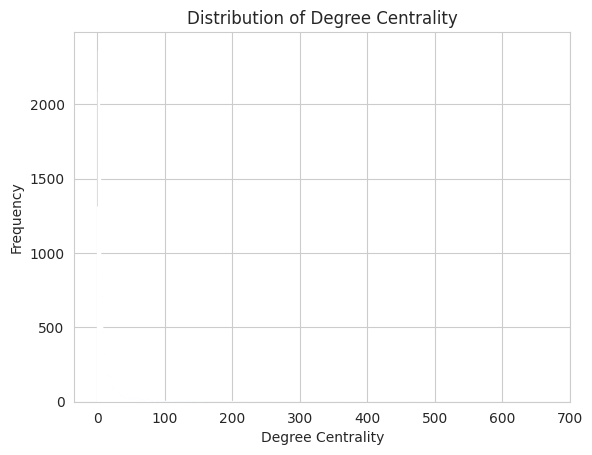

Detecting communities...
Running Clauset-Newman-Moore...
Running PLM community detection...
Converting node indices to names...


Processing eigenvector centrality: 100%|██████████| 16391/16391 [00:00<00:00, 1406568.26it/s]


Results:
Degree Centrality: [('Stanford University', 667.0), ('University College London', 612.0), ('University of Oxford', 561.0), ('Harvard University', 529.0), ('University of Cambridge', 523.0), ('Imperial College London', 484.0), ('Massachusetts Institute of Technology', 471.0), ('University of Michigan–Ann Arbor', 467.0), ('Columbia University', 467.0), ('University of Toronto', 465.0)]
Closeness Centrality: [('Frank Lloyd Wright School of Architecture', 0.5), ('Dayton VA Medical Center', 0.5), ('Sierra Club', 0.5), ('Poly Prep Country Day School', 0.5), ('Universal Music Group (United States)', 0.5), ('PayPal (United States)', 0.5), ('NBCUniversal (United States)', 0.5), ('University Health Care System', 0.5), ('Lokmanya Tilak Municipal General Hospital and Lokmanya Tilak Municipal Medical College', 0.5), ('Sarah Cannon', 0.5)]
Betweenness Centrality: [('Imperial College London', 0.01887456453875615), ('University College London', 0.016559074621992687), ('University of Oxford',

In [ ]:
## Network analysis
# Calculate degree centrality (considering weights)
print("Calculating degree centrality...")
deg_centrality = nk.centrality.DegreeCentrality(projected_graph, ignoreSelfLoops=True)
deg_centrality.run()
degree_centrality_result = deg_centrality.ranking()

# Calculate closeness centrality for each connected component
print("Calculating closeness centrality...")
components = nk.components.ConnectedComponents(projected_graph).run()
closeness_centrality_result = []

for component in tqdm(components.getComponents(), desc="Processing components"):
    subgraph = nk.graphtools.subgraphFromNodes(projected_graph, component)
    closeness_centrality = nk.centrality.Closeness(subgraph, True, subgraph.upperNodeIdBound())
    closeness_centrality.run()
    closeness_centrality_result.extend(closeness_centrality.ranking())

# Sort the combined results
closeness_centrality_result.sort(key=lambda x: x[1], reverse=True)

# Calculate betweenness centrality
print("Calculating betweenness centrality...")
betweenness_centrality = nk.centrality.Betweenness(projected_graph, normalized=True)
betweenness_centrality.run()
betweenness_centrality_result = betweenness_centrality.ranking()

# Calculate eigenvector centrality
print("Calculating eigenvector centrality...")
eigenvector_centrality = nk.centrality.EigenvectorCentrality(projected_graph)
eigenvector_centrality.run()
eigenvector_centrality_result = eigenvector_centrality.ranking()

# Summarize the network
print("Calculating basic network metrics...")
num_nodes = projected_graph.numberOfNodes()
num_edges = projected_graph.numberOfEdges()
density = nk.graphtools.density(projected_graph)

# Extract largest connected component
largest_component = nk.components.ConnectedComponents.extractLargestConnectedComponent(projected_graph, True)

# Calculate diameter of the largest component
print("Calculating diameter...")
diam = nk.distance.Diameter(largest_component, algo=1)
diam.run()
diameter = diam.getDiameter()

# Calculate average shortest path length for the largest component
print("Calculating average shortest path length...")
apsp = nk.distance.APSP(largest_component).run()
distances = apsp.getDistances()

total_distance = 0
total_pairs = 0

for i, row in enumerate(tqdm(distances, desc="Processing distances")):
    for dist in row:
        if dist < float('inf'):
            total_distance += dist
            total_pairs += 1

avg_shortest_path_length = total_distance / total_pairs if total_pairs > 0 else float('inf')

# Calculate clustering coefficient
print("Calculating clustering coefficient...")
clustering_coefficient_result = nk.globals.clustering(projected_graph)

num_components = components.numberOfComponents()
largest_component_size = largest_component.numberOfNodes()

# Calculate the degree distribution
print("Calculating degree distribution...")
dc = nk.centrality.DegreeCentrality(projected_graph)
dc.run()
scores = dc.scores()

# Fit the degree distribution to a power law
print("Fitting power law...")
fit = powerlaw.Fit(scores)
power_law_value = fit.power_law.alpha

# Plot the degree distribution (optional)
degree_counts = {}
for score in tqdm(scores, desc="Computing degree counts"):
    if score in degree_counts:
        degree_counts[score] += 1
    else:
        degree_counts[score] = 1

plt.bar(degree_counts.keys(), degree_counts.values())
plt.xlabel('Degree Centrality')
plt.ylabel('Frequency')
plt.title('Distribution of Degree Centrality')
plt.show()

# Community detection
print("Detecting communities...")
print("Running Clauset-Newman-Moore...")
communities = greedy_modularity_communities(nx_projected_graph)
num_communities_nx = len(communities)

print("Running PLM community detection...")
community_detector = nk.community.PLM(projected_graph)
community_detector.run()
num_communities_nk = len(community_detector.getPartition().getSubsetIds())

# Convert indices back to node names for centrality measures
print("Converting node indices to names...")
reverse_institution_map = {v: k for k, v in institution_map.items()}
degree_centrality_named = [(reverse_institution_map[node], centrality) for node, centrality in tqdm(degree_centrality_result, desc="Processing degree centrality")]
closeness_centrality_named = [(reverse_institution_map[node], centrality) for node, centrality in tqdm(closeness_centrality_result, desc="Processing closeness centrality")]
betweenness_centrality_named = [(reverse_institution_map[node], centrality) for node, centrality in tqdm(betweenness_centrality_result, desc="Processing betweenness centrality")]
eigenvector_centrality_named = [(reverse_institution_map[node], centrality) for node, centrality in tqdm(eigenvector_centrality_result, desc="Processing eigenvector centrality")]

# Print results
print("\nResults:")
print("Degree Centrality:", degree_centrality_named[:10])  # Top 10 nodes
print("Closeness Centrality:", closeness_centrality_named[:10])  # Top 10 nodes
print("Betweenness Centrality:", betweenness_centrality_named[:10])  # Top 10 nodes
print("Eigenvector Centrality:", eigenvector_centrality_named[:10])  # Top 10 nodes

print("\nNetwork Statistics:")
print("Number of Nodes:", num_nodes)
print("Number of Edges:", num_edges)
print("Density:", density)
print("Diameter of Largest Component:", diameter)
print("Average Shortest Path Length:", avg_shortest_path_length)
print("Clustering Coefficient:", clustering_coefficient_result)
print("Number of Components:", num_components)
print("Size of Largest Component:", largest_component_size)
print("Power-law Exponent:", power_law_value)
print("Number of Communities (Networkit - PLM):", num_communities_nk)
print("Number of Communities (NetworkX - Clauset-Newman-Moore):", num_communities_nx)

In [ ]:
# Save the projected graph as a CSV file
edges = []
for u in range(projected_graph.numberOfNodes()):
    for v in projected_graph.iterNeighbors(u):
        weight = projected_graph.weight(u, v)
        edges.append([reverse_institution_map[u], reverse_institution_map[v], weight])

projected_institutions_edgelist = pd.DataFrame(edges, columns=['source', 'target', 'weight'])
projected_institutions_edgelist.to_csv('/content/drive/MyDrive/Project - LLM science of science/data_network/MLpapers_institutions_projected_edgelist.csv', index=False)

print("Projected graph saved as 'projected_graph.csv'.")

Projected graph saved as 'projected_graph.csv'.


In [ ]:
file_path = '/content/drive/MyDrive/Project - LLM science of science/data_network/institutions_projected_edgelist.csv'
projected_df = pd.read_csv(file_path)

# Create a weighted graph from the dataframe
G = nx.from_pandas_edgelist(projected_df, 'source', 'target', ['weight'])

# List of nodes directly connected to Harvard University
harvard_connected_nodes = list(G.neighbors('Harvard University'))
print('Institutions connected to Harvard University:')
print(harvard_connected_nodes)

# Analyze Harvard University as an intermediary
intermediary_connections = []

for node in harvard_connected_nodes:
    for connected_node in G.neighbors(node):
        if connected_node != 'Harvard University' and connected_node not in harvard_connected_nodes:
            weight = G[node][connected_node]['weight'] if 'weight' in G[node][connected_node] else 1
            intermediary_connections.append((node, connected_node, weight))

# Count frequency of intermediary connections considering weights
intermediary_counter = Counter()
for node, connected_node, weight in intermediary_connections:
    intermediary_counter[(node, connected_node)] += weight

# Prepare the data for the CSV file
intermediary_data = [{'Connection': f'{connection[0]} - {connection[1]}', 'Frequency': freq} for connection, freq in intermediary_counter.items()]

# Create a DataFrame and save to CSV
intermediary_df = pd.DataFrame(intermediary_data)
intermediary_df.to_csv('harvard_intermediary_connections.csv', index=False)

Institutions connected to Harvard University:
['University of Iowa', 'IBM Research - Thomas J. Watson Research Center', 'Institut de Biologia Molecular de Barcelona', 'Free University of Bozen-Bolzano', "Boston Children's Museum", 'Case Western Reserve University', 'Johns Hopkins University', 'Tân Tạo University', 'University of Rhode Island', 'VA Palo Alto Health Care System', 'Ho Chi Minh City Medicine and Pharmacy University', 'University of Ulster', 'University of Chicago', 'Oklahoma State University', 'Peter Doherty Institute', 'Yale University', 'Stanford University', 'Dalhousie University', 'University of Cambridge', 'Université de Moncton', 'Columbia University', 'University of Surrey', 'IBM (United States)', 'Mass General Brigham', 'University of Waterloo', 'University of Edinburgh', 'Singapore University of Technology and Design', "Brigham and Women's Hospital", 'Broad Institute', 'Norwegian University of Science and Technology', 'University of California System', 'Vanderbilt

In [ ]:
file_path = '/content/drive/MyDrive/Project - LLM science of science/data_network/institutions_projected_edgelist.csv'
projected_df = pd.read_csv(file_path)

# Create a weighted graph from the dataframe
G = nx.from_pandas_edgelist(projected_df, 'source', 'target', ['weight'])

# List of nodes directly connected to University College London
UCL_connected_nodes = list(G.neighbors('University College London'))
print('Institutions connected to University College London:')
print(UCL_connected_nodes)

# Analyze University College London as an intermediary
intermediary_connections = []

for node in UCL_connected_nodes:
    for connected_node in G.neighbors(node):
        if connected_node != 'University College London' and connected_node not in UCL_connected_nodes:
            weight = G[node][connected_node]['weight'] if 'weight' in G[node][connected_node] else 1
            intermediary_connections.append((node, connected_node, weight))

# Count frequency of intermediary connections considering weights
intermediary_counter = Counter()
for node, connected_node, weight in intermediary_connections:
    intermediary_counter[(node, connected_node)] += weight

# Prepare the data for the CSV file
intermediary_data = [{'Connection': f'{connection[0]} - {connection[1]}', 'Frequency': freq} for connection, freq in intermediary_counter.items()]

# Create a DataFrame and save to CSV
intermediary_df = pd.DataFrame(intermediary_data)
intermediary_df.to_csv('UCL_intermediary_connections.csv', index=False)

Institutions connected to University College London:
['Harbin Institute of Technology', 'University of Cyprus', 'Inova Fairfax Hospital', 'Icahn School of Medicine at Mount Sinai', 'Imam Abdulrahman Bin Faisal University', 'Johns Hopkins University', 'University of Greifswald', 'National Yang Ming Chiao Tung University', 'Beaujon Hospital', 'Humboldt-Universität zu Berlin', 'Stanford University', 'King Faisal Specialist Hospital & Research Centre', 'University of Cambridge', 'Columbia University Irving Medical Center', 'University of Surrey', 'Dartmouth College', 'Frimley Health NHS Foundation Trust', 'American Academy of Ophthalmology', 'Binghamton University', 'Health Data Research UK', 'Princess Nourah bint Abdulrahman University', 'University of Salerno', 'University of Edinburgh', 'Instituto de Biomedicina de Sevilla', 'Technical University of Munich', 'Atlanta VA Medical Center', 'Norwegian University of Science and Technology', 'University of Liverpool', 'Chalmers University of 

### by Countries

In [ ]:
# Load the data from the file
file_path = '/content/drive/MyDrive/Project - LLM science of science/updated_dataset/ml-information-entropy.csv'
df = pd.read_csv(file_path)

# Affiliation_countries is in a list format
df['affiliation_countries'] = df['country_codes'].apply(eval)

# Create an edgelist
edgelist = []
for index, row in df.iterrows():
    title = row['title']
    countries = row['affiliation_countries']
    for countries in countries:
        edgelist.append((title, countries))

# Convert the edgelist to a DataFrame
edgelist_df = pd.DataFrame(edgelist, columns=['source', 'target'])

# Save the edgelist to a CSV file
edgelist_df.to_csv('/content/drive/MyDrive/Project - LLM science of science/data_network/MLpapers_countries_entropy_edgelist.csv', index=False)

print("Edgelist created and saved as 'edgelist.csv'.")

Edgelist created and saved as 'edgelist.csv'.


In [ ]:
# Map nodes to indices
node_map = {}
index = 0

def get_node_index(node):
    global index
    if node not in node_map:
        node_map[node] = index
        index += 1
    return node_map[node]

# Determine the number of unique nodes
num_nodes = len(set(edgelist_df['source']).union(set(edgelist_df['target'])))

# Create a bipartite graph with the predefined number of nodes
B = nk.graph.Graph(num_nodes, weighted=True, directed=False)

# Add edges to the bipartite graph
for _, row in edgelist_df.iterrows():
    paper = get_node_index(row['source'])
    countries = get_node_index(row['target'])
    B.addEdge(paper, countries)

In [ ]:
# Collect country
countries = set()
for _, row in tqdm(edgelist_df.iterrows(), desc="Collecting country", total=len(edgelist_df)):
    countries.add(row['target'])

# Create a projection onto country
projected_graph = nk.graph.Graph(len(countries), weighted=True, directed=False)

# Map country to indices in the projected graph
country_map = {disc: i for i, disc in enumerate(countries)}

# Initialize a dictionary to hold the edge weights
edge_weights = {}

# Add edges between country that share at least one paper, with weights
for _, row in tqdm(edgelist_df.iterrows(), desc="Building edge weights", total=len(edgelist_df)):
    paper = get_node_index(row['source'])
    country = country_map[row['target']]
    for neighbor in B.iterNeighbors(paper):
        neighbor_country = None
        for key, value in node_map.items():
            if value == neighbor:
                if key in countries:
                    neighbor_country = country_map[key]
                    break
        if neighbor_country is not None and neighbor_country != country:
            if (country, neighbor_country) in edge_weights:
                edge_weights[(country, neighbor_country)] += 1
            elif (neighbor_country, country) in edge_weights:
                edge_weights[(neighbor_country, country)] += 1
            else:
                edge_weights[(country, neighbor_country)] = 1

# Add edges with weights to the projected graph
for (u, v), weight in tqdm(edge_weights.items(), desc="Adding weighted edges", total=len(edge_weights)):
    projected_graph.addEdge(u, v, weight)

Adding weighted edges: 100%|██████████| 2967/2967 [00:00<00:00, 1071324.03it/s]


In [ ]:
# Convert Networkit graph to NetworkX graph
def networkit_to_networkx(nk_graph):
    nx_graph = nx.Graph()
    for u in nk_graph.iterNodes():
        nx_graph.add_node(u)
    for u, v in nk_graph.iterEdges():
        nx_graph.add_edge(u, v, weight=nk_graph.weight(u, v))
    return nx_graph

# Create projected graph
projected_graph = nk.graph.Graph(len(countries), weighted=True, directed=False)
for (u, v), weight in edge_weights.items():
    projected_graph.addEdge(u, v, weight)

# Convert projected graph to NetworkX graph
nx_projected_graph = networkit_to_networkx(projected_graph)

Calculating degree centrality...
Calculating closeness centrality...


Processing components: 100%|██████████| 5/5 [00:00<00:00, 2084.44it/s]


Calculating betweenness centrality...
Calculating eigenvector centrality...
Calculating basic network metrics...
Calculating diameter...
Calculating average shortest path length...


Processing distances: 100%|██████████| 174/174 [00:00<00:00, 17233.20it/s]
Values less than or equal to 0 in data. Throwing out 0 or negative values


Calculating clustering coefficient...
Calculating degree distribution...
Fitting power law...
Calculating best minimal value for power law fit


Computing degree counts: 100%|██████████| 178/178 [00:00<00:00, 692565.97it/s]


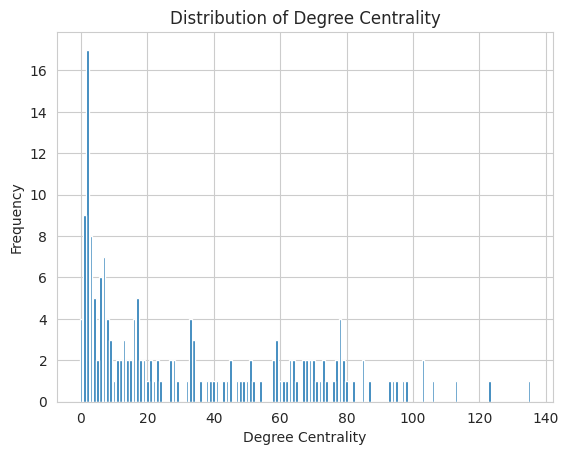

Detecting communities...
Running Clauset-Newman-Moore...
Running PLM community detection...
Converting node indices to names...


Processing eigenvector centrality: 100%|██████████| 178/178 [00:00<00:00, 1086733.79it/s]


Results:
Degree Centrality: [('US', 135.0), ('GB', 123.0), ('IN', 113.0), ('CN', 106.0), ('DE', 103.0), ('CA', 103.0), ('IT', 98.0), ('AU', 97.0), ('FR', 95.0), ('ES', 94.0)]
Closeness Centrality: [('SN', 0.16666666666666666), ('PH', 0.1657088122605364), ('BD', 0.1632075471698113), ('LV', 0.16048237476808905), ('ES', 0.15930018416206262), ('NG', 0.1572727272727273), ('NZ', 0.1572727272727273), ('CH', 0.15641952983725135), ('CA', 0.15641952983725135), ('MK', 0.15613718411552346)]
Betweenness Centrality: [('US', 0.08871044385229314), ('GB', 0.08339772941601621), ('CA', 0.06292921905853292), ('SN', 0.058093481832000166), ('NG', 0.05166981191781025), ('BD', 0.049416618123965236), ('AU', 0.0485887676634118), ('SA', 0.048207417732348254), ('CH', 0.04174304708343728), ('TR', 0.040902257319068484)]
Eigenvector Centrality: [('US', 0.599839188521805), ('GB', 0.4234736223674269), ('DE', 0.326229803675064), ('CN', 0.32404082226553566), ('CA', 0.22021032667883791), ('IT', 0.19057999832852332), ('E

In [ ]:
## Network analysis
# Calculate degree centrality (considering weights)
print("Calculating degree centrality...")
deg_centrality = nk.centrality.DegreeCentrality(projected_graph, ignoreSelfLoops=True)
deg_centrality.run()
degree_centrality_result = deg_centrality.ranking()

# Calculate closeness centrality for each connected component
print("Calculating closeness centrality...")
components = nk.components.ConnectedComponents(projected_graph).run()
closeness_centrality_result = []

for component in tqdm(components.getComponents(), desc="Processing components"):
    subgraph = nk.graphtools.subgraphFromNodes(projected_graph, component)
    closeness_centrality = nk.centrality.Closeness(subgraph, True, subgraph.upperNodeIdBound())
    closeness_centrality.run()
    closeness_centrality_result.extend(closeness_centrality.ranking())

# Sort the combined results
closeness_centrality_result.sort(key=lambda x: x[1], reverse=True)

# Calculate betweenness centrality
print("Calculating betweenness centrality...")
betweenness_centrality = nk.centrality.Betweenness(projected_graph, normalized=True)
betweenness_centrality.run()
betweenness_centrality_result = betweenness_centrality.ranking()

# Calculate eigenvector centrality
print("Calculating eigenvector centrality...")
eigenvector_centrality = nk.centrality.EigenvectorCentrality(projected_graph)
eigenvector_centrality.run()
eigenvector_centrality_result = eigenvector_centrality.ranking()

# Summarize the network
print("Calculating basic network metrics...")
num_nodes = projected_graph.numberOfNodes()
num_edges = projected_graph.numberOfEdges()
density = nk.graphtools.density(projected_graph)

# Extract largest connected component
largest_component = nk.components.ConnectedComponents.extractLargestConnectedComponent(projected_graph, True)

# Calculate diameter of the largest component
print("Calculating diameter...")
diam = nk.distance.Diameter(largest_component, algo=1)
diam.run()
diameter = diam.getDiameter()

# Calculate average shortest path length for the largest component
print("Calculating average shortest path length...")
apsp = nk.distance.APSP(largest_component).run()
distances = apsp.getDistances()

total_distance = 0
total_pairs = 0

for i, row in enumerate(tqdm(distances, desc="Processing distances")):
    for dist in row:
        if dist < float('inf'):
            total_distance += dist
            total_pairs += 1

avg_shortest_path_length = total_distance / total_pairs if total_pairs > 0 else float('inf')

# Calculate clustering coefficient
print("Calculating clustering coefficient...")
clustering_coefficient_result = nk.globals.clustering(projected_graph)

num_components = components.numberOfComponents()
largest_component_size = largest_component.numberOfNodes()

# Calculate the degree distribution
print("Calculating degree distribution...")
dc = nk.centrality.DegreeCentrality(projected_graph)
dc.run()
scores = dc.scores()

# Fit the degree distribution to a power law
print("Fitting power law...")
fit = powerlaw.Fit(scores)
power_law_value = fit.power_law.alpha

# Plot the degree distribution (optional)
degree_counts = {}
for score in tqdm(scores, desc="Computing degree counts"):
    if score in degree_counts:
        degree_counts[score] += 1
    else:
        degree_counts[score] = 1

plt.bar(degree_counts.keys(), degree_counts.values())
plt.xlabel('Degree Centrality')
plt.ylabel('Frequency')
plt.title('Distribution of Degree Centrality')
plt.show()

# Community detection
print("Detecting communities...")
print("Running Clauset-Newman-Moore...")
communities = greedy_modularity_communities(nx_projected_graph)
num_communities_nx = len(communities)

print("Running PLM community detection...")
community_detector = nk.community.PLM(projected_graph)
community_detector.run()
num_communities_nk = len(community_detector.getPartition().getSubsetIds())

# Convert indices back to node names for centrality measures
print("Converting node indices to names...")
reverse_country_map = {v: k for k, v in country_map.items()}
degree_centrality_named = [(reverse_country_map[node], centrality) for node, centrality in tqdm(degree_centrality_result, desc="Processing degree centrality")]
closeness_centrality_named = [(reverse_country_map[node], centrality) for node, centrality in tqdm(closeness_centrality_result, desc="Processing closeness centrality")]
betweenness_centrality_named = [(reverse_country_map[node], centrality) for node, centrality in tqdm(betweenness_centrality_result, desc="Processing betweenness centrality")]
eigenvector_centrality_named = [(reverse_country_map[node], centrality) for node, centrality in tqdm(eigenvector_centrality_result, desc="Processing eigenvector centrality")]

# Print results
print("\nResults:")
print("Degree Centrality:", degree_centrality_named[:10])  # Top 10 nodes
print("Closeness Centrality:", closeness_centrality_named[:10])  # Top 10 nodes
print("Betweenness Centrality:", betweenness_centrality_named[:10])  # Top 10 nodes
print("Eigenvector Centrality:", eigenvector_centrality_named[:10])  # Top 10 nodes

print("\nNetwork Statistics:")
print("Number of Nodes:", num_nodes)
print("Number of Edges:", num_edges)
print("Density:", density)
print("Diameter of Largest Component:", diameter)
print("Average Shortest Path Length:", avg_shortest_path_length)
print("Clustering Coefficient:", clustering_coefficient_result)
print("Number of Components:", num_components)
print("Size of Largest Component:", largest_component_size)
print("Power-law Exponent:", power_law_value)
print("Number of Communities (Networkit - PLM):", num_communities_nk)
print("Number of Communities (NetworkX - Clauset-Newman-Moore):", num_communities_nx)

In [ ]:
# Save the projected graph as a CSV file
edges = []
for u in range(projected_graph.numberOfNodes()):
    for v in projected_graph.iterNeighbors(u):
        weight = projected_graph.weight(u, v)
        edges.append([reverse_country_map[u], reverse_country_map[v], weight])

projected_country_edgelist = pd.DataFrame(edges, columns=['source', 'target', 'weight'])
projected_country_edgelist.to_csv('/content/drive/MyDrive/Project - LLM science of science/data_network/MLpapers_countries_projected_edgelist.csv', index=False)

print("Projected graph saved as 'projected_graph.csv'.")

Projected graph saved as 'projected_graph.csv'.


# CONTROL GROUP - NON LLM papers


### by Disciplines

In [ ]:
# Load the data from the file
file_path = '/content/drive/MyDrive/Project - LLM science of science/updated_dataset/non-llm-information-entropy.csv'
df = pd.read_csv(file_path)

# Affiliation_disciplines is in a list format
df['affiliation_disciplines'] = df['departments'].apply(eval)

# Create an edgelist
edgelist = []
for index, row in df.iterrows():
    title = row['title']
    disciplines = row['affiliation_disciplines']
    for discipline in disciplines:
        edgelist.append((title, discipline))

# Convert the edgelist to a DataFrame
edgelist_df = pd.DataFrame(edgelist, columns=['source', 'target'])

# Save the edgelist to a CSV file
edgelist_df.to_csv('/content/drive/MyDrive/Project - LLM science of science/data_network/Non-LLM_disciplines_entropy_edgelist.csv', index=False)

print("Edgelist created and saved as 'edgelist.csv'.")

<ipython-input-17-598d25804055>:3: DtypeWarning: Columns (32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Edgelist created and saved as 'edgelist.csv'.


In [ ]:
# Map nodes to indices
node_map = {}
index = 0

def get_node_index(node):
    global index
    if node not in node_map:
        node_map[node] = index
        index += 1
    return node_map[node]

# Determine the number of unique nodes
num_nodes = len(set(edgelist_df['source']).union(set(edgelist_df['target'])))

# Create a bipartite graph with the predefined number of nodes
B = nk.graph.Graph(num_nodes, weighted=True, directed=False)

# Add edges to the bipartite graph
for _, row in edgelist_df.iterrows():
    paper = get_node_index(row['source'])
    discipline = get_node_index(row['target'])
    B.addEdge(paper, discipline)

In [ ]:
# Collect disciplines
disciplines = set()
for _, row in tqdm(edgelist_df.iterrows(), desc="Collecting disciplines", total=len(edgelist_df)):
    disciplines.add(row['target'])

# Create a projection onto disciplines
projected_graph = nk.graph.Graph(len(disciplines), weighted=True, directed=False)

# Map disciplines to indices in the projected graph
discipline_map = {disc: i for i, disc in enumerate(disciplines)}

# Initialize a dictionary to hold the edge weights
edge_weights = {}

# Add edges between disciplines that share at least one paper, with weights
for _, row in tqdm(edgelist_df.iterrows(), desc="Building edge weights", total=len(edgelist_df)):
    paper = get_node_index(row['source'])
    discipline = discipline_map[row['target']]
    for neighbor in B.iterNeighbors(paper):
        neighbor_discipline = None
        for key, value in node_map.items():
            if value == neighbor:
                if key in disciplines:
                    neighbor_discipline = discipline_map[key]
                    break
        if neighbor_discipline is not None and neighbor_discipline != discipline:
            if (discipline, neighbor_discipline) in edge_weights:
                edge_weights[(discipline, neighbor_discipline)] += 1
            elif (neighbor_discipline, discipline) in edge_weights:
                edge_weights[(neighbor_discipline, discipline)] += 1
            else:
                edge_weights[(discipline, neighbor_discipline)] = 1

# Add edges with weights to the projected graph
for (u, v), weight in tqdm(edge_weights.items(), desc="Adding weighted edges", total=len(edge_weights)):
    projected_graph.addEdge(u, v, weight)

Adding weighted edges: 100%|██████████| 94901/94901 [00:00<00:00, 1245657.56it/s]


In [ ]:
# Convert Networkit graph to NetworkX graph
def networkit_to_networkx(nk_graph):
    nx_graph = nx.Graph()
    for u in nk_graph.iterNodes():
        nx_graph.add_node(u)
    for u, v in nk_graph.iterEdges():
        nx_graph.add_edge(u, v, weight=nk_graph.weight(u, v))
    return nx_graph

# Create projected graph
projected_graph = nk.graph.Graph(len(disciplines), weighted=True, directed=False)
for (u, v), weight in edge_weights.items():
    projected_graph.addEdge(u, v, weight)

# Convert projected graph to NetworkX graph
nx_projected_graph = networkit_to_networkx(projected_graph)

Calculating degree centrality...
Calculating closeness centrality...


Processing components: 100%|██████████| 4686/4686 [00:35<00:00, 131.04it/s]


Calculating betweenness centrality...
Calculating eigenvector centrality...
Calculating basic network metrics...
Calculating diameter...
Calculating average shortest path length...


Processing distances: 100%|██████████| 20649/20649 [02:16<00:00, 151.28it/s]
Values less than or equal to 0 in data. Throwing out 0 or negative values


Calculating clustering coefficient...
Calculating degree distribution...
Fitting power law...
Calculating best minimal value for power law fit


Computing degree counts: 100%|██████████| 26492/26492 [00:00<00:00, 1711997.74it/s]


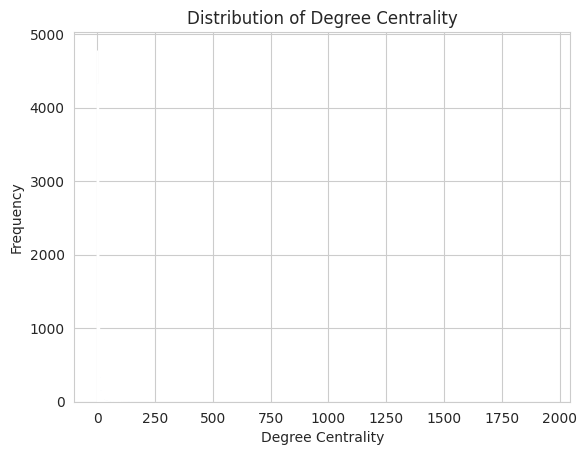

Detecting communities...
Running Clauset-Newman-Moore...
Running PLM community detection...
Converting node indices to names...


Processing eigenvector centrality: 100%|██████████| 26492/26492 [00:00<00:00, 1488845.29it/s]


Results:
Degree Centrality: [('Medicine', 1948.0), ('Chemistry', 1278.0), ('Physics', 1007.0), ('Public Health', 996.0), ('Biology', 879.0), ('Pathology', 874.0), ('Internal Medicine', 817.0), ('Pediatrics', 813.0), ('Psychology', 777.0), ('Pharmacy', 771.0)]
Closeness Centrality: [('Rail Systems Management', 0.5), ('Aviation Management', 0.5), ('Computing Science; Computer Science', 0.5), ('Control, Robotics and Electrical Engineering; Mathematics', 0.5), ('Applied Analysis and Stochastics', 0.5), ('Applied Mathematics and Mechanics', 0.5), ('Philosophy, Practical and Systematic Theology', 0.5), ('Children and Youth Ministry', 0.5), ('Education and Continuing Training', 0.5), ('Sciences, Society, Historicity, Education, Practices', 0.5)]
Betweenness Centrality: [('Medicine', 0.04118395362877872), ('Chemistry', 0.03697010754942357), ('Mechanical Engineering', 0.030330649333378368), ('Engineering', 0.029310382308629552), ('Physics', 0.029003320490934077), ('Public Health', 0.0272854067

In [ ]:
## Network analysis
# Calculate degree centrality (considering weights)
print("Calculating degree centrality...")
deg_centrality = nk.centrality.DegreeCentrality(projected_graph, ignoreSelfLoops=True)
deg_centrality.run()
degree_centrality_result = deg_centrality.ranking()

# Calculate closeness centrality for each connected component
print("Calculating closeness centrality...")
components = nk.components.ConnectedComponents(projected_graph).run()
closeness_centrality_result = []

for component in tqdm(components.getComponents(), desc="Processing components"):
    subgraph = nk.graphtools.subgraphFromNodes(projected_graph, component)
    closeness_centrality = nk.centrality.Closeness(subgraph, True, subgraph.upperNodeIdBound())
    closeness_centrality.run()
    closeness_centrality_result.extend(closeness_centrality.ranking())

# Sort the combined results
closeness_centrality_result.sort(key=lambda x: x[1], reverse=True)

# Calculate betweenness centrality
print("Calculating betweenness centrality...")
betweenness_centrality = nk.centrality.Betweenness(projected_graph, normalized=True)
betweenness_centrality.run()
betweenness_centrality_result = betweenness_centrality.ranking()

# Calculate eigenvector centrality
print("Calculating eigenvector centrality...")
eigenvector_centrality = nk.centrality.EigenvectorCentrality(projected_graph)
eigenvector_centrality.run()
eigenvector_centrality_result = eigenvector_centrality.ranking()

# Summarize the network
print("Calculating basic network metrics...")
num_nodes = projected_graph.numberOfNodes()
num_edges = projected_graph.numberOfEdges()
density = nk.graphtools.density(projected_graph)

# Extract largest connected component
largest_component = nk.components.ConnectedComponents.extractLargestConnectedComponent(projected_graph, True)

# Calculate diameter of the largest component
print("Calculating diameter...")
diam = nk.distance.Diameter(largest_component, algo=1)
diam.run()
diameter = diam.getDiameter()

# Calculate average shortest path length for the largest component
print("Calculating average shortest path length...")
apsp = nk.distance.APSP(largest_component).run()
distances = apsp.getDistances()

total_distance = 0
total_pairs = 0

for i, row in enumerate(tqdm(distances, desc="Processing distances")):
    for dist in row:
        if dist < float('inf'):
            total_distance += dist
            total_pairs += 1

avg_shortest_path_length = total_distance / total_pairs if total_pairs > 0 else float('inf')

# Calculate clustering coefficient
print("Calculating clustering coefficient...")
clustering_coefficient_result = nk.globals.clustering(projected_graph)

num_components = components.numberOfComponents()
largest_component_size = largest_component.numberOfNodes()

# Calculate the degree distribution
print("Calculating degree distribution...")
dc = nk.centrality.DegreeCentrality(projected_graph)
dc.run()
scores = dc.scores()

# Fit the degree distribution to a power law
print("Fitting power law...")
fit = powerlaw.Fit(scores)
power_law_value = fit.power_law.alpha

# Plot the degree distribution (optional)
degree_counts = {}
for score in tqdm(scores, desc="Computing degree counts"):
    if score in degree_counts:
        degree_counts[score] += 1
    else:
        degree_counts[score] = 1

plt.bar(degree_counts.keys(), degree_counts.values())
plt.xlabel('Degree Centrality')
plt.ylabel('Frequency')
plt.title('Distribution of Degree Centrality')
plt.show()

# Community detection
print("Detecting communities...")
print("Running Clauset-Newman-Moore...")
communities = greedy_modularity_communities(nx_projected_graph)
num_communities_nx = len(communities)

print("Running PLM community detection...")
community_detector = nk.community.PLM(projected_graph)
community_detector.run()
num_communities_nk = len(community_detector.getPartition().getSubsetIds())

# Convert indices back to node names for centrality measures
print("Converting node indices to names...")
reverse_discipline_map = {v: k for k, v in discipline_map.items()}
degree_centrality_named = [(reverse_discipline_map[node], centrality) for node, centrality in tqdm(degree_centrality_result, desc="Processing degree centrality")]
closeness_centrality_named = [(reverse_discipline_map[node], centrality) for node, centrality in tqdm(closeness_centrality_result, desc="Processing closeness centrality")]
betweenness_centrality_named = [(reverse_discipline_map[node], centrality) for node, centrality in tqdm(betweenness_centrality_result, desc="Processing betweenness centrality")]
eigenvector_centrality_named = [(reverse_discipline_map[node], centrality) for node, centrality in tqdm(eigenvector_centrality_result, desc="Processing eigenvector centrality")]

# Print results
print("\nResults:")
print("Degree Centrality:", degree_centrality_named[:10])  # Top 10 nodes
print("Closeness Centrality:", closeness_centrality_named[:10])  # Top 10 nodes
print("Betweenness Centrality:", betweenness_centrality_named[:10])  # Top 10 nodes
print("Eigenvector Centrality:", eigenvector_centrality_named[:10])  # Top 10 nodes

print("\nNetwork Statistics:")
print("Number of Nodes:", num_nodes)
print("Number of Edges:", num_edges)
print("Density:", density)
print("Diameter of Largest Component:", diameter)
print("Average Shortest Path Length:", avg_shortest_path_length)
print("Clustering Coefficient:", clustering_coefficient_result)
print("Number of Components:", num_components)
print("Size of Largest Component:", largest_component_size)
print("Power-law Exponent:", power_law_value)
print("Number of Communities (Networkit - PLM):", num_communities_nk)
print("Number of Communities (NetworkX - Clauset-Newman-Moore):", num_communities_nx)

In [ ]:
# Save the projected graph as a CSV file
edges = []
for u in range(projected_graph.numberOfNodes()):
    for v in projected_graph.iterNeighbors(u):
        weight = projected_graph.weight(u, v)
        edges.append([reverse_discipline_map[u], reverse_discipline_map[v], weight])

projected_disciplines_edgelist = pd.DataFrame(edges, columns=['source', 'target', 'weight'])
projected_disciplines_edgelist.to_csv('/content/drive/MyDrive/Project - LLM science of science/data_network/Non-LLM_disciplines_projected_edgelist.csv', index=False)

print("Projected graph saved as 'projected_graph.csv'.")

Projected graph saved as 'projected_graph.csv'.


In [ ]:
file_path = '/content/drive/MyDrive/Project - LLM science of science/data_network/disciplines_projected_edgelist.csv'
projected_df = pd.read_csv(file_path)

# Create a weighted graph from the dataframe
G = nx.from_pandas_edgelist(projected_df, 'source', 'target', ['weight'])

# List of nodes directly connected to Computer Science
CS_connected_nodes = list(G.neighbors('Computer Science'))
print('Disciplines connected to Computer Science:')
print(CS_connected_nodes)

# Analyze Computer Science as an intermediary
intermediary_connections = []

for node in CS_connected_nodes:
    for connected_node in G.neighbors(node):
        if connected_node != 'Computer Science' and connected_node not in CS_connected_nodes:
            weight = G[node][connected_node]['weight'] if 'weight' in G[node][connected_node] else 1
            intermediary_connections.append((node, connected_node, weight))

# Count frequency of intermediary connections considering weights
intermediary_counter = Counter()
for node, connected_node, weight in intermediary_connections:
    intermediary_counter[(node, connected_node)] += weight

# Prepare the data for the CSV file
intermediary_data = [{'Connection': f'{connection[0]} - {connection[1]}', 'Frequency': freq} for connection, freq in intermediary_counter.items()]

# Create a DataFrame and save to CSV
intermediary_df = pd.DataFrame(intermediary_data)
intermediary_df.to_csv('CS_intermediary_connections.csv', index=False)

Disciplines connected to Computer Science:
['Neurology', 'Geospatial Data Science', 'English', 'Computer Science & Information Engineering', 'Chemistry', 'Natural Language Processing', 'Chinese Information Processing', 'Scientific Research', 'Pathology and Immunology', 'Interaction', 'Chemical Technology', 'Electronic and Computer Engineering', 'Telecommunication Systems Management', 'AI Lab', 'Health Information', 'Natural Sciences', 'Social Science and Humanities', 'Economic Sciences', 'Electronic and Communications Engineering', 'Human Language Technology', 'Cognitive Science', 'Information and Physical Sciences', 'Finance & Economics', 'Advanced Research Computing', 'Information Technology Application Innovation', 'Information and Electronics', 'Computer Vision', 'Anesthesiology and Pain Medicine', 'General Surgery', 'Contents Research', 'Geography and Environment', 'Cultural Sciences', 'Prosthodontics', 'Bio-Med Big Data', 'Epidemiology and Population Health', 'Computing and Commu

In [ ]:
file_path = '/content/drive/MyDrive/Project - LLM science of science/data_network/disciplines_projected_edgelist.csv'
projected_df = pd.read_csv(file_path)

# Create a weighted graph from the dataframe
G = nx.from_pandas_edgelist(projected_df, 'source', 'target', ['weight'])

# List of nodes directly connected to Medicine
MEDICINE_connected_nodes = list(G.neighbors('Medicine'))
print('Disciplines connected to Medicine:')
print(MEDICINE_connected_nodes)

# Analyze Medicine as an intermediary
intermediary_connections = []

for node in MEDICINE_connected_nodes:
    for connected_node in G.neighbors(node):
        if connected_node != 'Medicine' and connected_node not in MEDICINE_connected_nodes:
            weight = G[node][connected_node]['weight'] if 'weight' in G[node][connected_node] else 1
            intermediary_connections.append((node, connected_node, weight))

# Count frequency of intermediary connections considering weights
intermediary_counter = Counter()
for node, connected_node, weight in intermediary_connections:
    intermediary_counter[(node, connected_node)] += weight

# Prepare the data for the MEDICINEV file
intermediary_data = [{'Connection': f'{connection[0]} - {connection[1]}', 'Frequency': freq} for connection, freq in intermediary_counter.items()]

# Create a DataFrame and save to MEDICINEV
intermediary_df = pd.DataFrame(intermediary_data)
intermediary_df.to_csv('MEDICINE_intermediary_connections.csv', index=False)

Disciplines connected to Medicine:
['Neurology', 'Artificial Intelligence in Healthcare', 'Cognitive and Brain Sciences', 'Chemistry', 'Natural Language Processing', 'Pathology and Immunology', 'Behavioral Health and Technology', "Men's Health: Aging and Metabolism", 'Clinical Cell Therapy', 'Physiotherapy', 'Health Information', 'Health Care Policy and Research', 'Data-Driven Insights and Innovation', 'Anesthesiology and Pharmacology', 'Computational Precision Health', 'Math and Computer', 'Surgical Outcomes Research', 'General Surgery', 'Plastic surgeon', 'Epidemiology and Population Health', 'Epidemiology', 'Child and Adolescent Psychiatry', 'Health Research Methods', 'Future Studies', 'Applied Science', 'Public Health and Human Sciences', 'Industrial Engineering and Engineering Management', 'Human Performance, Health Informatics and Information Management', 'Biomedical Informatics Research', 'Biomedical', 'Otolaryngology-Head and Neck Surgery', 'Health Policy and Administration', '

In [ ]:
### calculate the intermediaries (the facilitators of LLMs research)

In [ ]:
print(projected_graph.numberOfNodes(), projected_graph.numberOfEdges())

6604 16811


### by Institutions


In [ ]:
# Load the data from the file
file_path = '/content/drive/MyDrive/Project - LLM science of science/updated_dataset/non-llm-information-entropy.csv'
df = pd.read_csv(file_path)

# Affiliation_institutions is in a list format
df['affiliation_institutions'] = df['institutions'].apply(eval)

# Create an edgelist
edgelist = []
for index, row in df.iterrows():
    title = row['title']
    institutions = row['affiliation_institutions']
    for institution in institutions:
        edgelist.append((title, institution))

# Convert the edgelist to a DataFrame
edgelist_df = pd.DataFrame(edgelist, columns=['source', 'target'])

# Save the edgelist to a CSV file
edgelist_df.to_csv('/content/drive/MyDrive/Project - LLM science of science/data_network/Non-LLM_institutions_entropy_edgelist.csv', index=False)

print("Edgelist created and saved as 'edgelist.csv'.")

<ipython-input-5-f272b849aa76>:3: DtypeWarning: Columns (32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Edgelist created and saved as 'edgelist.csv'.


In [ ]:
# Map nodes to indices
node_map = {}
index = 0

def get_node_index(node):
    global index
    if node not in node_map:
        node_map[node] = index
        index += 1
    return node_map[node]

# Determine the number of unique nodes
num_nodes = len(set(edgelist_df['source']).union(set(edgelist_df['target'])))

# Create a bipartite graph with the predefined number of nodes
B = nk.graph.Graph(num_nodes, weighted=True, directed=False)

# Add edges to the bipartite graph
for _, row in edgelist_df.iterrows():
    paper = get_node_index(row['source'])
    institution = get_node_index(row['target'])
    B.addEdge(paper, institution)

In [ ]:
# Collect institutions
institutions = set()
for _, row in tqdm(edgelist_df.iterrows(), desc="Collecting institutions", total=len(edgelist_df)):
    institutions.add(row['target'])

# Create a projection onto institutions
projected_graph = nk.graph.Graph(len(institutions), weighted=True, directed=False)

# Map institutions to indices in the projected graph
institution_map = {disc: i for i, disc in enumerate(institutions)}

# Initialize a dictionary to hold the edge weights
edge_weights = {}

# Add edges between institutions that share at least one paper, with weights
for _, row in tqdm(edgelist_df.iterrows(), desc="Building edge weights", total=len(edgelist_df)):
    paper = get_node_index(row['source'])
    institution = institution_map[row['target']]
    for neighbor in B.iterNeighbors(paper):
        neighbor_institution = None
        for key, value in node_map.items():
            if value == neighbor:
                if key in institutions:
                    neighbor_institution = institution_map[key]
                    break
        if neighbor_institution is not None and neighbor_institution != institution:
            if (institution, neighbor_institution) in edge_weights:
                edge_weights[(institution, neighbor_institution)] += 1
            elif (neighbor_institution, institution) in edge_weights:
                edge_weights[(neighbor_institution, institution)] += 1
            else:
                edge_weights[(institution, neighbor_institution)] = 1

# Add edges with weights to the projected graph
for (u, v), weight in tqdm(edge_weights.items(), desc="Adding weighted edges", total=len(edge_weights)):
    projected_graph.addEdge(u, v, weight)

Adding weighted edges: 100%|██████████| 104649/104649 [00:00<00:00, 1316636.43it/s]


In [ ]:
# Convert Networkit graph to NetworkX graph
def networkit_to_networkx(nk_graph):
    nx_graph = nx.Graph()
    for u in nk_graph.iterNodes():
        nx_graph.add_node(u)
    for u, v in nk_graph.iterEdges():
        nx_graph.add_edge(u, v, weight=nk_graph.weight(u, v))
    return nx_graph

# Create projected graph
projected_graph = nk.graph.Graph(len(institutions), weighted=True, directed=False)
for (u, v), weight in edge_weights.items():
    projected_graph.addEdge(u, v, weight)

# Convert projected graph to NetworkX graph
nx_projected_graph = networkit_to_networkx(projected_graph)

Calculating degree centrality...
Calculating closeness centrality...


Processing components: 100%|██████████| 3113/3113 [00:20<00:00, 154.02it/s]


Calculating betweenness centrality...
Calculating eigenvector centrality...
Calculating basic network metrics...
Calculating diameter...
Calculating average shortest path length...


Processing distances: 100%|██████████| 15426/15426 [01:11<00:00, 214.79it/s]
Values less than or equal to 0 in data. Throwing out 0 or negative values


Calculating clustering coefficient...
Calculating degree distribution...
Fitting power law...
Calculating best minimal value for power law fit


Computing degree counts: 100%|██████████| 19010/19010 [00:00<00:00, 1682749.49it/s]


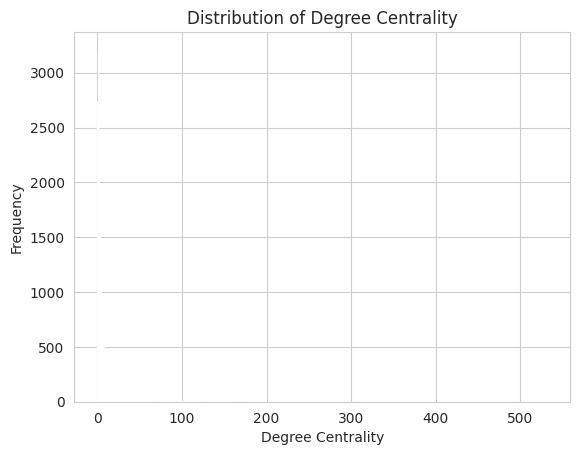

Detecting communities...
Running Clauset-Newman-Moore...
Running PLM community detection...
Converting node indices to names...


Processing eigenvector centrality: 100%|██████████| 19010/19010 [00:00<00:00, 1645283.29it/s]


Results:
Degree Centrality: [('Centre National de la Recherche Scientifique', 532.0), ('University College London', 437.0), ('University of California, Los Angeles', 393.0), ('University of Toronto', 393.0), ('University of Oxford', 376.0), ('University of California, San Diego', 370.0), ('Ludwig-Maximilians-Universität München', 357.0), ('University of Bologna', 356.0), ('Chinese Academy of Sciences', 352.0), ('Université Paris Cité', 351.0)]
Closeness Centrality: [('Organisation de Coopération et de Développement Economiques', 0.5), ('Bank of Canada', 0.5), ('Natural History Society of Northumbria', 0.5), ('Royal Horticultural Society', 0.5), ('National University of San Luis', 0.5), ('Universidad Nacional de La Pampa', 0.5), ('Academic City College University', 0.5), ('Wisconsin International University College', 0.5), ('Columbia Theological Seminary', 0.5), ('Claremont Colleges', 0.5)]
Betweenness Centrality: [('King Saud University', 0.01671124946575221), ('University of Toronto'

In [ ]:
## Network analysis
# Calculate degree centrality (considering weights)
print("Calculating degree centrality...")
deg_centrality = nk.centrality.DegreeCentrality(projected_graph, ignoreSelfLoops=True)
deg_centrality.run()
degree_centrality_result = deg_centrality.ranking()

# Calculate closeness centrality for each connected component
print("Calculating closeness centrality...")
components = nk.components.ConnectedComponents(projected_graph).run()
closeness_centrality_result = []

for component in tqdm(components.getComponents(), desc="Processing components"):
    subgraph = nk.graphtools.subgraphFromNodes(projected_graph, component)
    closeness_centrality = nk.centrality.Closeness(subgraph, True, subgraph.upperNodeIdBound())
    closeness_centrality.run()
    closeness_centrality_result.extend(closeness_centrality.ranking())

# Sort the combined results
closeness_centrality_result.sort(key=lambda x: x[1], reverse=True)

# Calculate betweenness centrality
print("Calculating betweenness centrality...")
betweenness_centrality = nk.centrality.Betweenness(projected_graph, normalized=True)
betweenness_centrality.run()
betweenness_centrality_result = betweenness_centrality.ranking()

# Calculate eigenvector centrality
print("Calculating eigenvector centrality...")
eigenvector_centrality = nk.centrality.EigenvectorCentrality(projected_graph)
eigenvector_centrality.run()
eigenvector_centrality_result = eigenvector_centrality.ranking()

# Summarize the network
print("Calculating basic network metrics...")
num_nodes = projected_graph.numberOfNodes()
num_edges = projected_graph.numberOfEdges()
density = nk.graphtools.density(projected_graph)

# Extract largest connected component
largest_component = nk.components.ConnectedComponents.extractLargestConnectedComponent(projected_graph, True)

# Calculate diameter of the largest component
print("Calculating diameter...")
diam = nk.distance.Diameter(largest_component, algo=1)
diam.run()
diameter = diam.getDiameter()

# Calculate average shortest path length for the largest component
print("Calculating average shortest path length...")
apsp = nk.distance.APSP(largest_component).run()
distances = apsp.getDistances()

total_distance = 0
total_pairs = 0

for i, row in enumerate(tqdm(distances, desc="Processing distances")):
    for dist in row:
        if dist < float('inf'):
            total_distance += dist
            total_pairs += 1

avg_shortest_path_length = total_distance / total_pairs if total_pairs > 0 else float('inf')

# Calculate clustering coefficient
print("Calculating clustering coefficient...")
clustering_coefficient_result = nk.globals.clustering(projected_graph)

num_components = components.numberOfComponents()
largest_component_size = largest_component.numberOfNodes()

# Calculate the degree distribution
print("Calculating degree distribution...")
dc = nk.centrality.DegreeCentrality(projected_graph)
dc.run()
scores = dc.scores()

# Fit the degree distribution to a power law
print("Fitting power law...")
fit = powerlaw.Fit(scores)
power_law_value = fit.power_law.alpha

# Plot the degree distribution (optional)
degree_counts = {}
for score in tqdm(scores, desc="Computing degree counts"):
    if score in degree_counts:
        degree_counts[score] += 1
    else:
        degree_counts[score] = 1

plt.bar(degree_counts.keys(), degree_counts.values())
plt.xlabel('Degree Centrality')
plt.ylabel('Frequency')
plt.title('Distribution of Degree Centrality')
plt.show()

# Community detection
print("Detecting communities...")
print("Running Clauset-Newman-Moore...")
communities = greedy_modularity_communities(nx_projected_graph)
num_communities_nx = len(communities)

print("Running PLM community detection...")
community_detector = nk.community.PLM(projected_graph)
community_detector.run()
num_communities_nk = len(community_detector.getPartition().getSubsetIds())

# Convert indices back to node names for centrality measures
print("Converting node indices to names...")
reverse_institution_map = {v: k for k, v in institution_map.items()}
degree_centrality_named = [(reverse_institution_map[node], centrality) for node, centrality in tqdm(degree_centrality_result, desc="Processing degree centrality")]
closeness_centrality_named = [(reverse_institution_map[node], centrality) for node, centrality in tqdm(closeness_centrality_result, desc="Processing closeness centrality")]
betweenness_centrality_named = [(reverse_institution_map[node], centrality) for node, centrality in tqdm(betweenness_centrality_result, desc="Processing betweenness centrality")]
eigenvector_centrality_named = [(reverse_institution_map[node], centrality) for node, centrality in tqdm(eigenvector_centrality_result, desc="Processing eigenvector centrality")]

# Print results
print("\nResults:")
print("Degree Centrality:", degree_centrality_named[:10])  # Top 10 nodes
print("Closeness Centrality:", closeness_centrality_named[:10])  # Top 10 nodes
print("Betweenness Centrality:", betweenness_centrality_named[:10])  # Top 10 nodes
print("Eigenvector Centrality:", eigenvector_centrality_named[:10])  # Top 10 nodes

print("\nNetwork Statistics:")
print("Number of Nodes:", num_nodes)
print("Number of Edges:", num_edges)
print("Density:", density)
print("Diameter of Largest Component:", diameter)
print("Average Shortest Path Length:", avg_shortest_path_length)
print("Clustering Coefficient:", clustering_coefficient_result)
print("Number of Components:", num_components)
print("Size of Largest Component:", largest_component_size)
print("Power-law Exponent:", power_law_value)
print("Number of Communities (Networkit - PLM):", num_communities_nk)
print("Number of Communities (NetworkX - Clauset-Newman-Moore):", num_communities_nx)

In [ ]:
# Save the projected graph as a CSV file
edges = []
for u in range(projected_graph.numberOfNodes()):
    for v in projected_graph.iterNeighbors(u):
        weight = projected_graph.weight(u, v)
        edges.append([reverse_institution_map[u], reverse_institution_map[v], weight])

projected_institutions_edgelist = pd.DataFrame(edges, columns=['source', 'target', 'weight'])
projected_institutions_edgelist.to_csv('/content/drive/MyDrive/Project - LLM science of science/data_network/MLpapers_institutions_projected_edgelist.csv', index=False)

print("Projected graph saved as 'projected_graph.csv'.")

Projected graph saved as 'projected_graph.csv'.


In [ ]:
file_path = '/content/drive/MyDrive/Project - LLM science of science/data_network/institutions_projected_edgelist.csv'
projected_df = pd.read_csv(file_path)

# Create a weighted graph from the dataframe
G = nx.from_pandas_edgelist(projected_df, 'source', 'target', ['weight'])

# List of nodes directly connected to Harvard University
harvard_connected_nodes = list(G.neighbors('Harvard University'))
print('Institutions connected to Harvard University:')
print(harvard_connected_nodes)

# Analyze Harvard University as an intermediary
intermediary_connections = []

for node in harvard_connected_nodes:
    for connected_node in G.neighbors(node):
        if connected_node != 'Harvard University' and connected_node not in harvard_connected_nodes:
            weight = G[node][connected_node]['weight'] if 'weight' in G[node][connected_node] else 1
            intermediary_connections.append((node, connected_node, weight))

# Count frequency of intermediary connections considering weights
intermediary_counter = Counter()
for node, connected_node, weight in intermediary_connections:
    intermediary_counter[(node, connected_node)] += weight

# Prepare the data for the CSV file
intermediary_data = [{'Connection': f'{connection[0]} - {connection[1]}', 'Frequency': freq} for connection, freq in intermediary_counter.items()]

# Create a DataFrame and save to CSV
intermediary_df = pd.DataFrame(intermediary_data)
intermediary_df.to_csv('harvard_intermediary_connections.csv', index=False)

Institutions connected to Harvard University:
['University of Iowa', 'IBM Research - Thomas J. Watson Research Center', 'Institut de Biologia Molecular de Barcelona', 'Free University of Bozen-Bolzano', "Boston Children's Museum", 'Case Western Reserve University', 'Johns Hopkins University', 'Tân Tạo University', 'University of Rhode Island', 'VA Palo Alto Health Care System', 'Ho Chi Minh City Medicine and Pharmacy University', 'University of Ulster', 'University of Chicago', 'Oklahoma State University', 'Peter Doherty Institute', 'Yale University', 'Stanford University', 'Dalhousie University', 'University of Cambridge', 'Université de Moncton', 'Columbia University', 'University of Surrey', 'IBM (United States)', 'Mass General Brigham', 'University of Waterloo', 'University of Edinburgh', 'Singapore University of Technology and Design', "Brigham and Women's Hospital", 'Broad Institute', 'Norwegian University of Science and Technology', 'University of California System', 'Vanderbilt

In [ ]:
file_path = '/content/drive/MyDrive/Project - LLM science of science/data_network/institutions_projected_edgelist.csv'
projected_df = pd.read_csv(file_path)

# Create a weighted graph from the dataframe
G = nx.from_pandas_edgelist(projected_df, 'source', 'target', ['weight'])

# List of nodes directly connected to University College London
UCL_connected_nodes = list(G.neighbors('University College London'))
print('Institutions connected to University College London:')
print(UCL_connected_nodes)

# Analyze University College London as an intermediary
intermediary_connections = []

for node in UCL_connected_nodes:
    for connected_node in G.neighbors(node):
        if connected_node != 'University College London' and connected_node not in UCL_connected_nodes:
            weight = G[node][connected_node]['weight'] if 'weight' in G[node][connected_node] else 1
            intermediary_connections.append((node, connected_node, weight))

# Count frequency of intermediary connections considering weights
intermediary_counter = Counter()
for node, connected_node, weight in intermediary_connections:
    intermediary_counter[(node, connected_node)] += weight

# Prepare the data for the CSV file
intermediary_data = [{'Connection': f'{connection[0]} - {connection[1]}', 'Frequency': freq} for connection, freq in intermediary_counter.items()]

# Create a DataFrame and save to CSV
intermediary_df = pd.DataFrame(intermediary_data)
intermediary_df.to_csv('UCL_intermediary_connections.csv', index=False)

Institutions connected to University College London:
['Harbin Institute of Technology', 'University of Cyprus', 'Inova Fairfax Hospital', 'Icahn School of Medicine at Mount Sinai', 'Imam Abdulrahman Bin Faisal University', 'Johns Hopkins University', 'University of Greifswald', 'National Yang Ming Chiao Tung University', 'Beaujon Hospital', 'Humboldt-Universität zu Berlin', 'Stanford University', 'King Faisal Specialist Hospital & Research Centre', 'University of Cambridge', 'Columbia University Irving Medical Center', 'University of Surrey', 'Dartmouth College', 'Frimley Health NHS Foundation Trust', 'American Academy of Ophthalmology', 'Binghamton University', 'Health Data Research UK', 'Princess Nourah bint Abdulrahman University', 'University of Salerno', 'University of Edinburgh', 'Instituto de Biomedicina de Sevilla', 'Technical University of Munich', 'Atlanta VA Medical Center', 'Norwegian University of Science and Technology', 'University of Liverpool', 'Chalmers University of 

### by Countries

In [ ]:
# Load the data from the file
file_path = '/content/drive/MyDrive/Project - LLM science of science/updated_dataset/non-llm-information-entropy.csv'
df = pd.read_csv(file_path)

# Affiliation_countries is in a list format
df['affiliation_countries'] = df['country_codes'].apply(eval)

# Create an edgelist
edgelist = []
for index, row in df.iterrows():
    title = row['title']
    countries = row['affiliation_countries']
    for countries in countries:
        edgelist.append((title, countries))

# Convert the edgelist to a DataFrame
edgelist_df = pd.DataFrame(edgelist, columns=['source', 'target'])

# Save the edgelist to a CSV file
edgelist_df.to_csv('/content/drive/MyDrive/Project - LLM science of science/data_network/Non-LLM_countries_entropy_edgelist.csv', index=False)

print("Edgelist created and saved as 'edgelist.csv'.")

<ipython-input-23-9ad0e5fc978f>:3: DtypeWarning: Columns (32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Edgelist created and saved as 'edgelist.csv'.


In [ ]:
# Map nodes to indices
node_map = {}
index = 0

def get_node_index(node):
    global index
    if node not in node_map:
        node_map[node] = index
        index += 1
    return node_map[node]

# Determine the number of unique nodes
num_nodes = len(set(edgelist_df['source']).union(set(edgelist_df['target'])))

# Create a bipartite graph with the predefined number of nodes
B = nk.graph.Graph(num_nodes, weighted=True, directed=False)

# Add edges to the bipartite graph
for _, row in edgelist_df.iterrows():
    paper = get_node_index(row['source'])
    countries = get_node_index(row['target'])
    B.addEdge(paper, countries)

In [ ]:
# Collect country
countries = set()
for _, row in tqdm(edgelist_df.iterrows(), desc="Collecting country", total=len(edgelist_df)):
    countries.add(row['target'])

# Create a projection onto country
projected_graph = nk.graph.Graph(len(countries), weighted=True, directed=False)

# Map country to indices in the projected graph
country_map = {disc: i for i, disc in enumerate(countries)}

# Initialize a dictionary to hold the edge weights
edge_weights = {}

# Add edges between country that share at least one paper, with weights
for _, row in tqdm(edgelist_df.iterrows(), desc="Building edge weights", total=len(edgelist_df)):
    paper = get_node_index(row['source'])
    country = country_map[row['target']]
    for neighbor in B.iterNeighbors(paper):
        neighbor_country = None
        for key, value in node_map.items():
            if value == neighbor:
                if key in countries:
                    neighbor_country = country_map[key]
                    break
        if neighbor_country is not None and neighbor_country != country:
            if (country, neighbor_country) in edge_weights:
                edge_weights[(country, neighbor_country)] += 1
            elif (neighbor_country, country) in edge_weights:
                edge_weights[(neighbor_country, country)] += 1
            else:
                edge_weights[(country, neighbor_country)] = 1

# Add edges with weights to the projected graph
for (u, v), weight in tqdm(edge_weights.items(), desc="Adding weighted edges", total=len(edge_weights)):
    projected_graph.addEdge(u, v, weight)

Adding weighted edges: 100%|██████████| 2721/2721 [00:00<00:00, 1356233.06it/s]


In [ ]:
# Convert Networkit graph to NetworkX graph
def networkit_to_networkx(nk_graph):
    nx_graph = nx.Graph()
    for u in nk_graph.iterNodes():
        nx_graph.add_node(u)
    for u, v in nk_graph.iterEdges():
        nx_graph.add_edge(u, v, weight=nk_graph.weight(u, v))
    return nx_graph

# Create projected graph
projected_graph = nk.graph.Graph(len(countries), weighted=True, directed=False)
for (u, v), weight in edge_weights.items():
    projected_graph.addEdge(u, v, weight)

# Convert projected graph to NetworkX graph
nx_projected_graph = networkit_to_networkx(projected_graph)

Calculating degree centrality...
Calculating closeness centrality...


Processing components: 100%|██████████| 10/10 [00:00<00:00, 3686.33it/s]


Calculating betweenness centrality...
Calculating eigenvector centrality...
Calculating basic network metrics...
Calculating diameter...
Calculating average shortest path length...


Processing distances: 100%|██████████| 187/187 [00:00<00:00, 15396.62it/s]
Values less than or equal to 0 in data. Throwing out 0 or negative values


Calculating clustering coefficient...
Calculating degree distribution...
Fitting power law...
Calculating best minimal value for power law fit


Computing degree counts: 100%|██████████| 196/196 [00:00<00:00, 841436.63it/s]


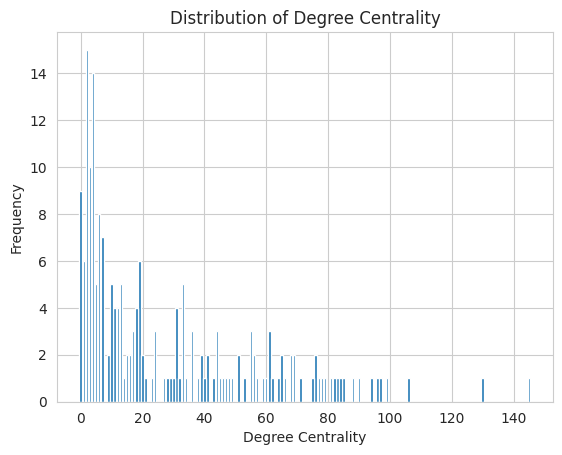

Detecting communities...
Running Clauset-Newman-Moore...
Running PLM community detection...
Converting node indices to names...


Processing eigenvector centrality: 100%|██████████| 196/196 [00:00<00:00, 1093196.26it/s]


Results:
Degree Centrality: [('US', 145.0), ('GB', 130.0), ('FR', 106.0), ('DE', 99.0), ('CN', 97.0), ('IN', 96.0), ('ES', 94.0), ('AU', 90.0), ('IT', 88.0), ('NL', 85.0)]
Closeness Centrality: [('LV', 0.15843270868824533), ('GR', 0.15422885572139303), ('PE', 0.15422885572139303), ('NO', 0.15397350993377484), ('PL', 0.15245901639344261), ('PK', 0.15220949263502456), ('CL', 0.15196078431372548), ('ZM', 0.15171288743882544), ('CM', 0.15171288743882544), ('KE', 0.15171288743882544)]
Betweenness Centrality: [('GB', 0.07302727628132676), ('US', 0.0657843356860772), ('NL', 0.05497324637936329), ('IN', 0.05190714773924242), ('KE', 0.05073946283413142), ('FR', 0.049280267513134246), ('CL', 0.046781691098375), ('ZA', 0.045646115533390076), ('NO', 0.039549440541421836), ('IT', 0.0351115618999324)]
Eigenvector Centrality: [('US', 0.5706753396264616), ('IT', 0.36595198044666044), ('DE', 0.3290443165581899), ('GB', 0.327466025750396), ('FR', 0.29033190525876296), ('CN', 0.2714370033767283), ('CA',

In [ ]:
## Network analysis
# Calculate degree centrality (considering weights)
print("Calculating degree centrality...")
deg_centrality = nk.centrality.DegreeCentrality(projected_graph, ignoreSelfLoops=True)
deg_centrality.run()
degree_centrality_result = deg_centrality.ranking()

# Calculate closeness centrality for each connected component
print("Calculating closeness centrality...")
components = nk.components.ConnectedComponents(projected_graph).run()
closeness_centrality_result = []

for component in tqdm(components.getComponents(), desc="Processing components"):
    subgraph = nk.graphtools.subgraphFromNodes(projected_graph, component)
    closeness_centrality = nk.centrality.Closeness(subgraph, True, subgraph.upperNodeIdBound())
    closeness_centrality.run()
    closeness_centrality_result.extend(closeness_centrality.ranking())

# Sort the combined results
closeness_centrality_result.sort(key=lambda x: x[1], reverse=True)

# Calculate betweenness centrality
print("Calculating betweenness centrality...")
betweenness_centrality = nk.centrality.Betweenness(projected_graph, normalized=True)
betweenness_centrality.run()
betweenness_centrality_result = betweenness_centrality.ranking()

# Calculate eigenvector centrality
print("Calculating eigenvector centrality...")
eigenvector_centrality = nk.centrality.EigenvectorCentrality(projected_graph)
eigenvector_centrality.run()
eigenvector_centrality_result = eigenvector_centrality.ranking()

# Summarize the network
print("Calculating basic network metrics...")
num_nodes = projected_graph.numberOfNodes()
num_edges = projected_graph.numberOfEdges()
density = nk.graphtools.density(projected_graph)

# Extract largest connected component
largest_component = nk.components.ConnectedComponents.extractLargestConnectedComponent(projected_graph, True)

# Calculate diameter of the largest component
print("Calculating diameter...")
diam = nk.distance.Diameter(largest_component, algo=1)
diam.run()
diameter = diam.getDiameter()

# Calculate average shortest path length for the largest component
print("Calculating average shortest path length...")
apsp = nk.distance.APSP(largest_component).run()
distances = apsp.getDistances()

total_distance = 0
total_pairs = 0

for i, row in enumerate(tqdm(distances, desc="Processing distances")):
    for dist in row:
        if dist < float('inf'):
            total_distance += dist
            total_pairs += 1

avg_shortest_path_length = total_distance / total_pairs if total_pairs > 0 else float('inf')

# Calculate clustering coefficient
print("Calculating clustering coefficient...")
clustering_coefficient_result = nk.globals.clustering(projected_graph)

num_components = components.numberOfComponents()
largest_component_size = largest_component.numberOfNodes()

# Calculate the degree distribution
print("Calculating degree distribution...")
dc = nk.centrality.DegreeCentrality(projected_graph)
dc.run()
scores = dc.scores()

# Fit the degree distribution to a power law
print("Fitting power law...")
fit = powerlaw.Fit(scores)
power_law_value = fit.power_law.alpha

# Plot the degree distribution (optional)
degree_counts = {}
for score in tqdm(scores, desc="Computing degree counts"):
    if score in degree_counts:
        degree_counts[score] += 1
    else:
        degree_counts[score] = 1

plt.bar(degree_counts.keys(), degree_counts.values())
plt.xlabel('Degree Centrality')
plt.ylabel('Frequency')
plt.title('Distribution of Degree Centrality')
plt.show()

# Community detection
print("Detecting communities...")
print("Running Clauset-Newman-Moore...")
communities = greedy_modularity_communities(nx_projected_graph)
num_communities_nx = len(communities)

print("Running PLM community detection...")
community_detector = nk.community.PLM(projected_graph)
community_detector.run()
num_communities_nk = len(community_detector.getPartition().getSubsetIds())

# Convert indices back to node names for centrality measures
print("Converting node indices to names...")
reverse_country_map = {v: k for k, v in country_map.items()}
degree_centrality_named = [(reverse_country_map[node], centrality) for node, centrality in tqdm(degree_centrality_result, desc="Processing degree centrality")]
closeness_centrality_named = [(reverse_country_map[node], centrality) for node, centrality in tqdm(closeness_centrality_result, desc="Processing closeness centrality")]
betweenness_centrality_named = [(reverse_country_map[node], centrality) for node, centrality in tqdm(betweenness_centrality_result, desc="Processing betweenness centrality")]
eigenvector_centrality_named = [(reverse_country_map[node], centrality) for node, centrality in tqdm(eigenvector_centrality_result, desc="Processing eigenvector centrality")]

# Print results
print("\nResults:")
print("Degree Centrality:", degree_centrality_named[:10])  # Top 10 nodes
print("Closeness Centrality:", closeness_centrality_named[:10])  # Top 10 nodes
print("Betweenness Centrality:", betweenness_centrality_named[:10])  # Top 10 nodes
print("Eigenvector Centrality:", eigenvector_centrality_named[:10])  # Top 10 nodes

print("\nNetwork Statistics:")
print("Number of Nodes:", num_nodes)
print("Number of Edges:", num_edges)
print("Density:", density)
print("Diameter of Largest Component:", diameter)
print("Average Shortest Path Length:", avg_shortest_path_length)
print("Clustering Coefficient:", clustering_coefficient_result)
print("Number of Components:", num_components)
print("Size of Largest Component:", largest_component_size)
print("Power-law Exponent:", power_law_value)
print("Number of Communities (Networkit - PLM):", num_communities_nk)
print("Number of Communities (NetworkX - Clauset-Newman-Moore):", num_communities_nx)

In [ ]:
# Save the projected graph as a CSV file
edges = []
for u in range(projected_graph.numberOfNodes()):
    for v in projected_graph.iterNeighbors(u):
        weight = projected_graph.weight(u, v)
        edges.append([reverse_country_map[u], reverse_country_map[v], weight])

projected_country_edgelist = pd.DataFrame(edges, columns=['source', 'target', 'weight'])
projected_country_edgelist.to_csv('/content/drive/MyDrive/Project - LLM science of science/data_network/Non-LLM_countries_projected_edgelist.csv', index=False)

print("Projected graph saved as 'projected_graph.csv'.")

Projected graph saved as 'projected_graph.csv'.


## Visualize networks

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# Load the edge list from the CSV file
file_path = '/content/drive/MyDrive/Project - LLM science of science/data_network/disciplines_projected_edgelist.csv'
edge_list = pd.read_csv(file_path)

# Initialize the graph
G = nx.Graph()

# Add edges from the edge list
for index, row in edge_list.iterrows():
    source, target, weight = row[0], row[1], row[2]
    G.add_edge(source, target, weight=weight)

# Detect communities using Clauset-Newman-Moore algorithm
communities = list(nx.community.greedy_modularity_communities(G))
community_map = {}
for i, community in enumerate(communities):
    for node in community:
        community_map[node] = i

# Get the color for each node
colors = [community_map[node] for node in G.nodes()]

# Draw the graph using the Yifan Hu layout
plt.figure(figsize=(12, 12))
pos = nx.kamada_kawai_layout(G)  # Kamada-Kawai layout
nx.draw(G, pos, node_color=colors, with_labels=False, node_size=20, cmap=plt.cm.tab20, edge_color='gray', width=0.5)
plt.title('Disciplines Projected Network (Yifan Hu Layout)')
plt.show()

# Comparisons between treatment vs control group structures

In [ ]:
from sklearn.metrics import jaccard_score
from scipy.spatial.distance import cosine
from sklearn.metrics import jaccard_score
from scipy.stats import ks_2samp
from scipy.stats import skew, kurtosis
from scipy.spatial.distance import canberra

In [ ]:
# Load the uploaded edgelists for LLM and Non-LLM papers
llm_file_path = '/content/drive/MyDrive/Project - LLM science of science/data_network/LLM_disciplines_projected_edgelist.csv'
non_llm_file_path = '/content/drive/MyDrive/Project - LLM science of science/data_network/ML_disciplines_projected_edgelist.csv'

llm_edgelist = pd.read_csv(llm_file_path)
non_llm_edgelist = pd.read_csv(non_llm_file_path)

# Display the first few rows of each file to understand their structure
llm_edgelist.head(), non_llm_edgelist.head()

(                                  source  \
 0  Environmental Sciences and Management   
 1                   Evidence in Medicine   
 2                   Evidence in Medicine   
 3                   Evidence in Medicine   
 4                   Evidence in Medicine   
 
                                               target  weight  
 0                             Environmental Sciences    12.0  
 1                                       Epidemiology    24.0  
 2                              Public Health Methods     6.0  
 3             Evidence-based Medicine and Evaluation    12.0  
 4  Epidemiology in Dermatology and Evaluation of ...     6.0  ,
                                               source  \
 0  Computational Geoscience and Reservoir Enginee...   
 1  Computational Geoscience and Reservoir Enginee...   
 2                   Information Systems Architecture   
 3                   Information Systems Architecture   
 4                   Information Systems Architecture   
 

In [ ]:
# Convert edgelists to networkx graphs
llm_graph = nx.from_pandas_edgelist(llm_edgelist, 'source', 'target', edge_attr=True)
non_llm_graph = nx.from_pandas_edgelist(non_llm_edgelist, 'source', 'target', edge_attr=True)

# Extract unique nodes from both networks
llm_nodes = set(llm_graph.nodes)
non_llm_nodes = set(non_llm_graph.nodes)

# Compute node overlap and Jaccard similarity for nodes
common_nodes = llm_nodes.intersection(non_llm_nodes)
node_overlap = len(common_nodes)
unique_llm_nodes = len(llm_nodes) - node_overlap
unique_non_llm_nodes = len(non_llm_nodes) - node_overlap
jaccard_nodes = len(common_nodes) / len(llm_nodes.union(non_llm_nodes))

# Extract edges from both networks
llm_edges = set(llm_graph.edges)
non_llm_edges = set(non_llm_graph.edges)

# Compute edge overlap
common_edges = llm_edges.intersection(non_llm_edges)
edge_overlap = len(common_edges)
unique_llm_edges = len(llm_edges) - edge_overlap
unique_non_llm_edges = len(non_llm_edges) - edge_overlap

# Flatten edge presence vectors for comparison
all_edges = sorted(llm_edges.union(non_llm_edges))
llm_edge_vector = [1 if edge in llm_edges else 0 for edge in all_edges]
non_llm_edge_vector = [1 if edge in non_llm_edges else 0 for edge in all_edges]

# Compute Jaccard similarity for edges
try:
    jaccard_edges = jaccard_score(llm_edge_vector, non_llm_edge_vector)
except ValueError:
    jaccard_edges = 0  # Fallback if vectors are zero-length or invalid

# Netsimile feature computation
def compute_netsimile_features(graph):
    """
    Compute all 7 NetSimile features.
    """
    degree_dict = dict(graph.degree())
    clustering_coeff_dict = nx.clustering(graph)
    avg_neighbor_degree_dict = nx.average_neighbor_degree(graph)

    features = []
    for node in graph.nodes:
        neighbors = list(graph.neighbors(node))
        degree = degree_dict.get(node, 0)
        clustering_coeff = clustering_coeff_dict.get(node, 0)
        avg_neighbor_degree = avg_neighbor_degree_dict.get(node, 0)

        # Compute egonet and related features
        egonet = graph.subgraph(neighbors)
        egonet_size = egonet.number_of_edges()
        egonet_density = nx.density(egonet) if len(neighbors) > 1 else 0
        outward_edges = degree - 2 * egonet_size

        # Average clustering coefficient of neighbors
        avg_neighbor_clustering = np.mean([clustering_coeff_dict.get(n, 0) for n in neighbors]) if neighbors else 0

        features.append([
            degree,
            clustering_coeff,
            egonet_size,
            egonet_density,
            outward_edges,
            avg_neighbor_degree,
            avg_neighbor_clustering
        ])

    return pd.DataFrame(features, columns=[
        "Degree",
        "Clustering",
        "Egonet Size",
        "Egonet Density",
        "Outward Edges",
        "AvgNeighborDegree",
        "AvgNeighborClustering"
    ])

# Compute Netsimile features for both networks
llm_features = compute_netsimile_features(llm_graph)
non_llm_features = compute_netsimile_features(non_llm_graph)

# Compute Canberra distance between aggregated Netsimile feature vectors
def aggregate_features(features_df):
    """
    Aggregate node-level features into a single feature vector for the graph.
    """
    aggregated = []
    for column in features_df.columns:
        data = features_df[column].dropna()
        aggregated.extend([
            np.mean(data),
            np.median(data),
            np.std(data),
            skew(data),
            kurtosis(data)
        ])
    return np.array(aggregated)

llm_signature = aggregate_features(llm_features)
non_llm_signature = aggregate_features(non_llm_features)
netsimile_distance = canberra(llm_signature, non_llm_signature)

# Perform Kolmogorov-Smirnov test for each feature
ks_results = {}
for column in llm_features.columns:
    llm_values = llm_features[column].dropna()
    non_llm_values = non_llm_features[column].dropna()
    ks_stat, ks_pval = ks_2samp(llm_values, non_llm_values)
    ks_results[column] = {"KS Statistic": ks_stat, "P-value": ks_pval}

# Summarize results
comparison_results = {
    "Node Overlap": node_overlap,
    "Unique LLM Nodes": unique_llm_nodes,
    "Unique Non-LLM Nodes": unique_non_llm_nodes,
    "Node Jaccard Similarity": jaccard_nodes,
    "Edge Overlap": edge_overlap,
    "Unique LLM Edges": unique_llm_edges,
    "Unique Non-LLM Edges": unique_non_llm_edges,
    "Edge Jaccard Similarity": jaccard_edges,
    "Netsimile Distance (Canberra)": netsimile_distance,
    "KS Test using Netsimile features": ks_results
}

# Output the results
comparison_results

{'Node Overlap': 3819,
 'Unique LLM Nodes': 4710,
 'Unique Non-LLM Nodes': 18601,
 'Node Jaccard Similarity': 0.14076667895318834,
 'Edge Overlap': 4503,
 'Unique LLM Edges': 28811,
 'Unique Non-LLM Edges': 117351,
 'Edge Jaccard Similarity': 0.029887498755517206,
 'Netsimile Distance (Canberra)': 6.35001584335371,
 'KS Test using Netsimile features': {'Degree': {'KS Statistic': 0.09928359025705341,
   'P-value': 1.7936517147856036e-53},
  'Clustering': {'KS Statistic': 0.08160180583450974,
   'P-value': 3.07202176226902e-36},
  'Egonet Size': {'KS Statistic': 0.11204664695954164,
   'P-value': 5.03233800433938e-68},
  'Egonet Density': {'KS Statistic': 0.08160180583450974,
   'P-value': 3.07202176226902e-36},
  'Outward Edges': {'KS Statistic': 0.1151898612374489,
   'P-value': 7.004167480107846e-72},
  'AvgNeighborDegree': {'KS Statistic': 0.28996210023439994, 'P-value': 0.0},
  'AvgNeighborClustering': {'KS Statistic': 0.07412472365625844,
   'P-value': 5.696085226697642e-30}}}